Autores: Natalia Rodríguez i Ashlie Ventura

# Pràctica 4: Similitud Lèxica i Semàntica

**Processament del Llenguatge Humà — Grau en Intel·ligència Artificial**

---

## Introducció

Aquesta pràctica té com a objectiu entrenar i avaluar models d'embeddings distribucionals i contextuals per a tasques de similitud en espanyol. El notebook fa alhora de codi i d'informe: tot el raonament, la justificació de decisions i l'anàlisi dels resultats es troben aquí, intercalats amb el codi que els produeix.

El treball s'organitza en tres parts que s'encadenen:

**Part 1 — Entrenament d'embeddings estàtics.** Entrenem models Word2Vec i fastText sobre el corpus de la Viquipèdia en espanyol (`raw.es`). Abans d'entrenar els models finals comparem totes les dimensions (25, 50, 100), fem un grid search per trobar els millors hiperparàmetres de context i arquitectura (paràmetres `window` i `sg`). Addicionalment, explorem l'efecte de la mida del corpus sobre la qualitat dels embeddings, una anàlisi complementària que l'enunciat proposa com a alternativa a la comparació de dimensions però que hem decidit incloure en tots dos casos per tenir un panorama més complet.

**Part 2 — Avaluació intrínseca (Multi-SimLex).** Avaluem els embeddings sobre el conjunt Multi-SimLex en espanyol: calculem la similitud cosinus entre els vectors de cada parell de paraules i la comparem amb el judici humà mitjançant la correlació de Spearman. Analitzem l'efecte de la dimensionalitat, la mida del corpus i la diferència respecte del fastText oficial de Facebook (300d, entrenat sobre Common Crawl).

**Part 3 — Avaluació extrínseca (Spanish STS).** Avaluem models per a la similitud semàntica de frases, mesurada amb la correlació de Pearson sobre el conjunt de test. Comparem quatre famílies de sistemes de complexitat creixent: baselines cosinus (mitjana simple i ponderada amb TF-IDF), un model seqüencial siamès (BiLSTM amb atenció) i un model contextual BERT siamès (BETO). Per als models que ho requereixen, es fa una cerca d'hiperparàmetres sobre el conjunt de dev, mai sobre test.

> **Nota important sobre el dataset STS.** L'enunciat proposava `PlanTL-GOB-ES/sts-es`, però les versions recents de la llibreria `datasets` ja no en suporten el *loading script*, i fixar una versió antiga generava conflictes amb `transformers`. S'ha substituït pel conjunt equivalent `mteb/sts17-crosslingual-sts` (parella `es-es`), que prové de la mateixa font (SemEval-2017, STS cross-lingual) però és considerablement més petit (≈250 parells en total). Aquesta escassetat condiciona de manera decisiva els resultats de la Part 3, tal com s'explica en detall a l'anàlisi final.

## Estructura del notebook

La Part 1 comprèn les seccions 1–9: entorn i imports, configuració global, preprocessament del corpus, preparació de Multi-SimLex, grid search de `window` i `sg`, entrenament dels models finals, càrrega del fastText oficial, resum de models i funcions d'accés als embeddings. La Part 2 s'ocupa de l'avaluació intrínseca (seccions P2-2 a P2-5) i la Part 3 de l'avaluació extrínseca (seccions P3-1 a P3-8), incloent-hi una anàlisi de robustesa opcional.


---
## 1. Instal·lació i imports

La cel·la de codi que segueix importa totes les llibreries necessàries per a la pràctica. S'han agrupat per funcionalitat: utilitats estàndard de Python (`os`, `re`, `json`, `logging`, `pickle`, `pathlib`), computació científica (`numpy`, `pandas`, `matplotlib`), models d'embeddings (`gensim`), aprenentatge profund (`torch`, `transformers`) i eines estadístiques (`scipy`). L'ús d'un únic bloc d'imports al principi facilita la reproducibilitat i evita importacions disperses al llarg del notebook.


In [75]:
import os
import re
import json
import logging
import pickle
from pathlib import Path
from typing import List, Dict, Optional, Iterator, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

# Gensim: Word2Vec i fastText
from gensim.models import Word2Vec, FastText as GensimFastText
from gensim.models.callbacks import CallbackAny2Vec

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.WARNING)
logger = logging.getLogger(__name__)
print("Imports OK")


Imports OK


---
## 2. Configuració global

Tots els paràmetres de la pràctica estan centralitzats al diccionari `CONFIG`. Aquesta decisió de disseny, que no forma part de l'enunciat però que hem adoptat explícitament, té tres avantatges pràctics: primer, qualsevol canvi de ruta o hiperparàmetre es fa en un sol lloc i es propaga automàticament a les Parts 2 i 3; segon, és fàcil veure d'un cop d'ull quins paràmetres s'han fixat a priori i quins s'han determinat per cerca; tercer, els models es carreguen des de disc quan ja existeixen (`FORCE_RETRAIN = False`), de manera que es pot reexecutar el notebook parcialmet sense tornar a entrenar des de zero.

Les decisions de configuració més rellevants, amb la seva justificació:

**`min_count = 5`:** Es descarten les paraules que apareixen menys de 5 vegades al corpus. Valors massa baixos (1–2) incorporen soroll tipogràfic i formes molt rares que perjudiquen la qualitat dels vectors; valors massa alts redueixen el vocabulari útil. 5 és el valor estàndard de la literatura per a corpus de Wikipedia.

**`workers = 8`:** Es fan servir 8 fils paral·lels per aprofitar els nuclis del processador disponibles. Gensim és capaç de paralelitzar l'entrenament eficientment amb múltiples fils.

**`epochs = 5`:** Com s'argumenta a la secció del grid search, 5 èpoques és suficient per a la convergència de Word2Vec i fastText sobre corpus grans; les Δ de pèrdua entre èpoques consecutives decauen dràsticament i el model s'estabilitza abans d'arribar a l'última iteració.

**`min_token_length = 2`:** Els tokens d'un sol caràcter (articles, preposicions aïllats, artefactes de preprocessament) s'eliminen perquè afegeixen soroll sense aportar informació semàntica útil.

**`embedding_dims = [25, 50, 100]`:** Les tres dimensions a comparar, tal com proposa l'enunciat. La tria és intencionada: 25 dimensions és el límit inferior pràctic per a embeddings de qualitat acceptable, 100 és el valor convencional per a models entrenats sobre corpus de mida mitjana, i 50 serveix de punt intermedi per traçar la corba de rendiments decresents.


In [76]:
# ══════════════════════════════════════════════════════════════
#  CONFIGURACIÓ GLOBAL  (llegida per les Parts 2 i 3)
# ══════════════════════════════════════════════════════════════

CONFIG = {
    # Rutes
    "corpus_dir"        : "data/raw.es/",
    "source_encoding"   : "cp1252",
    "processed_corpus"  : "data/corpus_processed.txt",
    "models_dir"        : "models/",

    # Preprocessament
    "max_sentences"     : None,   # None = corpus complet
    "min_token_length"  : 2,

    # Hiperparàmetres fixos (no depenen del grid search)
    "min_count"         : 5,
    "workers"           : 8,
    "epochs"            : 5,

    # Dimensions finals a comparar (s'afegirà dim_corpus automàticament)
    "embedding_dims"    : [25, 50, 100],

    # fastText oficial
    "fasttext_official_path" : "models/cc.es.300.bin",
    "fasttext_official_dim"  : 300,

    # Seed de reproducibilitat
    "seed"              : 42,

    # Hiperparàmetres òptims — es populen automàticament després del grid search
    # No els toquis a mà: el grid search els escriurà aquí.
    "best_window" : None,
    "best_sg"     : None,
}

for d in ["data", CONFIG["models_dir"]]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Configuració inicial carregada.")
print("  [INFO] best_window i best_sg seran populats pel grid search (secció 5).")


Configuració inicial carregada.
  [INFO] best_window i best_sg seran populats pel grid search (secció 5).


In [77]:
# Inspecció del corpus
corpus_dir   = Path(CONFIG["corpus_dir"])
corpus_files = sorted(corpus_dir.rglob("*")) if corpus_dir.exists() else []
corpus_files = [f for f in corpus_files if f.is_file()]


print(f"Fitxers al corpus: {len(corpus_files)}")
total_mb = sum(f.stat().st_size for f in corpus_files) / 1e6
print(f"Mida total: {total_mb:.0f} MB")
for f in corpus_files[:5]:
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")
if len(corpus_files) > 5:
    print(f"  ... i {len(corpus_files)-5} fitxers més")
print()
# Mostra les primeres línies
with open(corpus_files[0], encoding=CONFIG["source_encoding"], errors="replace") as fh:
    for i_line, line in enumerate(fh):
        if line.strip():
            print(line.rstrip()[:120])
        if i_line >= 6:
            break


Fitxers al corpus: 57
Mida total: 678 MB
  spanishText_10000_15000  (20.3 MB)
  spanishText_110000_115000  (14.6 MB)
  spanishText_120000_125000  (14.5 MB)
  spanishText_15000_20000  (26.5 MB)
  spanishText_180000_185000  (11.5 MB)
  ... i 52 fitxers més

<doc id="20540" title="658" nonfiltered="1" processed="1" dbindex="10000">
 Acontecimientos .
 Nacimientos .


---
## 3. Preprocessament del corpus

Abans d'entrenar els embeddings cal transformar els fitxers bruts del corpus (`raw.es`) en un format estàndard que Gensim pugui llegir: un fitxer de text (`corpus_processed.txt`) amb una frase per línia, on les paraules estan en minúscules i separades per espais.

El preprocessament que implementem fa les passes següents, en ordre: (1) es descarreguen les línies que comencen per `<` o `=`, que corresponen a etiquetes XML o a capçaleres de seccions de Viquipèdia i no aporten contingut lingüístic útil; (2) cada línia es parteix en frases independents usant com a delimitadors els signes de puntuació final (`.`, `!`, `?`), de manera que l'algorisme de Word2Vec pugui aprendre contextos dins de frases sense creuar fronteres de frase; (3) tot el text es passa a minúscules i es neteja eliminant qualsevol caràcter que no sigui lletra de l'alfabet espanyol (incloent-hi vocals accentuades, `ü` i `ñ`), apòstrof o guió, substituint-lo per un espai; (4) es col·lapsen els espais múltiples; i (5) es descarten els fragments que, després de la neteja, contenen menys de 3 tokens o tokens de menys de 2 caràcters.

La lectura i escriptura del corpus es fa de manera peresosa (lazy), és a dir, sense carregar mai tot el fitxer a memòria alhora. Això és necessari perquè el corpus complet supera els 200 MB i processar-lo en un sol bloc seria ineficient. La classe `SentenceIterator` encapsula aquesta lectura peresosa i és reutilitzada per Gensim durant l'entrenament.


In [78]:
_RE_CLEAN = re.compile(r"[^a-záéíóúüñ'\-]")
_RE_SPACES = re.compile(r"\s+")
_RE_SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")


def preprocess_fragment(fragment: str) -> Optional[List[str]]:
    fragment = fragment.strip()
    if not fragment:
        return None
    fragment = fragment.lower()
    fragment = _RE_CLEAN.sub(" ", fragment)
    fragment = _RE_SPACES.sub(" ", fragment).strip()
    tokens = [t for t in fragment.split() if len(t) >= CONFIG["min_token_length"]]
    return tokens if len(tokens) >= 3 else None


def preprocess_line(line: str) -> Optional[List[List[str]]]:
    line = line.strip()
    if not line or line.startswith("<") or line.startswith("="):
        return None
    sentences = []
    for fragment in _RE_SENT_SPLIT.split(line):
        tokens = preprocess_fragment(fragment)
        if tokens:
            sentences.append(tokens)
    return sentences if sentences else None


def build_processed_corpus(
    corpus_files: List[Path],
    output_path: str,
    max_sentences: Optional[int] = None,
    force_rebuild: bool = False,
) -> int:
    output_file = Path(output_path)
    if output_file.exists() and not force_rebuild:
        n = sum(1 for _ in open(output_file, encoding="utf-8"))
        print(f"El corpus processat ja existeix ({n:,} frases): {output_path}")
        return n
    if output_file.exists():
        output_file.unlink()
    total = 0
    with open(output_file, "w", encoding="utf-8") as out:
        for fpath in tqdm(corpus_files, desc="Fitxers"):
            with open(fpath, encoding=CONFIG["source_encoding"], errors="replace") as fh:
                for line in fh:
                    sentence_list = preprocess_line(line)
                    if sentence_list:
                        for tokens in sentence_list:
                            out.write(" ".join(tokens) + "\n")
                            total += 1
                            if max_sentences and total >= max_sentences:
                                print(f"  [max_sentences={max_sentences} assolit]")
                                return total
    print(f"Corpus processat: {total:,} frases -> {output_path}")
    return total

n_sentences = build_processed_corpus(
    corpus_files,
    CONFIG["processed_corpus"],
    max_sentences=CONFIG["max_sentences"],
    force_rebuild=False,
)
print(f"Total de frases: {n_sentences:,}")


El corpus processat ja existeix (5,461,482 frases): data/corpus_processed.txt
Total de frases: 5,461,482


In [79]:
class SentenceIterator:
    """Iterador perezós sobre corpus_processed.txt."""
    def __init__(self, path: str):
        self.path = path

    def __iter__(self) -> Iterator[List[str]]:
        with open(self.path, encoding="utf-8") as fh:
            for line in fh:
                tokens = line.rstrip().split()
                if tokens:
                    yield tokens

# Verificació ràpida
sentences = SentenceIterator(CONFIG["processed_corpus"])
for i, s in enumerate(sentences):
    print(s)
    if i >= 3:
        break


['fulgencio', 'de', 'écija', 'santo', 'español']
['erquinoaldo', 'mayordomo', 'franco', 'de', 'palacio', 'de', 'neustria']
['egilona', 'última', 'reina', 'visigoda', 'de', 'hispania']
['fin', 'del', 'califato', 'perfecto']


---
## 4. Preparació de Multi-SimLex

Multi-SimLex (Vulic et al., 2020) és un conjunt de dades de similitud semàntica lèxica que conté 1.888 parells de paraules anotats per jutges humans en múltiples idiomes, inclòs l'espanyol (fitxer `SPA.tsv`). Per a cada parell, el conjunt proporciona les puntuacions individuals de fins a 10 anotadors en una escala de 0 a 6, on 0 indica paraules sense cap relació semàntica i 6 indica paraules pràcticament sinònimes. El fitxer s'ha descarregat manualment des de `https://multisimlex.com`.

La **puntuació de similitud oficial** s'obté com la **mitjana aritmètica** de les puntuacions dels anotadors, d'acord amb el protocol estàndard de la publicació original. Això és important perquè el fitxer `SPA.tsv` original no inclou una columna `score` precalculada, sinó les columnes `Annotator 1` a `Annotator 10` de manera individual. La cel·la de càrrega que segueix s'encarrega d'aquest càlcul i normalitza els noms de columnes per garantir la compatibilitat independentment de la versió exacta del fitxer.

Aquesta puntuació es fa servir de dues maneres: primer, com a mètrica proxy durant el grid search (Secció 5) per seleccionar els hiperparàmetres òptims sense contaminar cap conjunt de test; i posteriorment, com a avaluació intrínseca dels models finals entrenats (Part 2).


In [80]:
# ── Càrrega i preparació de Multi-SimLex ────────────────────────────────────
#
# El fitxer SPA.tsv del Multi-SimLex conté les puntuacions individuals de cada
# anotador (columnes 'Annotator 1' a 'Annotator 10'). La puntuació de similitud
# oficial s'obté com la mitjana aritmètica d'aquests anotadors, seguint el
# protocol estàndard de Multi-SimLex (Vulic et al., 2020).
#
# Referència: https://multisimlex.com
# ─────────────────────────────────────────────────────────────────────────────

SIMLEX_PATH = "data/SPA.tsv"


# ── Càrrega i validació ───────────────────────────────────────────────────────
simlex_df = None

simlex_df = pd.read_csv(SIMLEX_PATH, sep="\t")
print(f"Multi-SimLex carregat: {len(simlex_df)} parells")
print(f"Columnes: {list(simlex_df.columns)}")

# ── Normalització robusta de noms de columnes ─────────────────────────
# Suporta tant el format original (Word 1, Word 2, Annotator X)
# com el format ja processat (word1, word2, score).
col_map = {}
annotator_cols = [c for c in simlex_df.columns if "annotator" in c.lower()]
if annotator_cols and "score" not in simlex_df.columns:
    # Format original: cal calcular la puntuació
    simlex_df["score"] = simlex_df[annotator_cols].mean(axis=1)
    print(f"[INFO] Puntuació calculada com a mitjana de {len(annotator_cols)} anotadors.")
for col in simlex_df.columns:
    cl = col.lower()
    if "word" in cl and "1" in cl: col_map[col] = "word1"
    elif "word" in cl and "2" in cl: col_map[col] = "word2"
simlex_df = simlex_df.rename(columns=col_map)

simlex_df["word1"] = simlex_df["word1"].str.lower().str.strip()
simlex_df["word2"] = simlex_df["word2"].str.lower().str.strip()
simlex_df["score"] = pd.to_numeric(simlex_df["score"], errors="coerce")
simlex_df = simlex_df.dropna(subset=["word1", "word2", "score"])
print(f"Parells vàlids: {len(simlex_df)}")
print(f"Rang de puntuacions: [{simlex_df['score'].min():.2f}, {simlex_df['score'].max():.2f}]")
print(simlex_df[["word1", "word2", "score"]].head(3).to_string(index=False))




Multi-SimLex carregat: 1888 parells
Columnes: ['ID', 'Word 1', 'Word 2', 'PoS', 'Annotator 1', 'Annotator 2', 'Annotator 3', 'Annotator 4', 'Annotator 5', 'Annotator 6', 'Annotator 7', 'Annotator 8', 'Annotator 9', 'Annotator 10']
[INFO] Puntuació calculada com a mitjana de 10 anotadors.
Parells vàlids: 1888
Rang de puntuacions: [0.00, 5.90]
     word1     word2  score
     brazo   músculo    1.4
democracia monarquía    1.3
    tejado     techo    4.8


---
## 5. Grid Search d'hiperparàmetres (`window` i `sg`)

### Per què primer el grid search i no entrenar directament?

L'objectiu principal de la pràctica és comparar l'efecte de la dimensionalitat dels embeddings (25, 50, 100). Per fer aquesta comparació de manera rigorosa, tots els models han de ser idèntics en tot excepte la dimensió: si cada model tingués el seu propi `window` o `sg`, no podríem atribuir les diferències de rendiment a la dimensió, perquè hauríem canviat múltiples variables alhora. El flux correcte és, doncs, primer trobar els millors hiperparàmetres fixos i després variar únicament la dimensió. Aquesta metodologia és estàndard en la literatura però no l'exigeix explícitament l'enunciat; l'hem incorporat perquè fa la comparació final més neta.

### Per què dim=100 per al grid i no una altra?

S'utilitza la dimensió més gran dels models que comparem. Si una configuració de `window`/`sg` funciona bé amb dim=100 (on el model té més capacitat per absorbir el context), és una elecció conservadora i segura per a les dimensions menors. A l'inrevés no seria vàlid: una configuració òptima per a dim=25 pot ser subòptima per a dim=100.

### Per què corpus reduït (1M de frases)?

S'utilitza un subcorpus d'1 milió de frases (d'un total de 5,46M) per agilitzar la cerca: el grid entrena 12 models i fer-ho sobre el corpus complet multiplicaria el cost per un factor de ~5 sense canviar el rànquing entre configuracions. Les relacions relatives entre `window` i `sg` es mantenen estables independentment de la mida del corpus, cosa que hem verificat comprovant que el rànquing és consistent a partir de l'epoch 3 en tots els models.

### Per què 5 epochs i no més?

5 epochs és el valor estàndard per a Word2Vec i fastText sobre corpus grans, i la verificació empírica confirma que és suficient. A diferència de les xarxes neuronals profundes, Word2Vec i fastText presenten una corba de convergència molt ràpida: els increments de pèrdua (Δ) decauen dràsticament i el model s'estabilitza en poques iteracions. Concretament, per al model més gran (W2V, corpus complet, dim=100) s'ha verificat que el Δ de pèrdua cau de 61M a l'epoch 1 fins a 2,7M a l'epoch 5, amb decrements cada cop més petits. Epochs addicionals aportarien un guany marginal a un cost computacional elevat. Cal tenir en compte que la *loss* reportada per Gensim amb `compute_loss=True` és acumulada (no per epoch), per tant sempre creix; el que mesura la convergència és el Δ entre epochs consecutives, no el valor absolut.

### Paràmetres explorats

La cerca combina les tres opcions de mida de context (`window ∈ {3, 5, 8}`) i els dos modes d'entrenament (`sg ∈ {0 (CBOW), 1 (Skip-gram)}`), formant 6 combinacions, cadascuna provada tant amb Word2Vec com amb fastText, totalitzant **12 models** de grid. La dimensió es fixa a 100 i el corpus a 1M de frases. Els resultats es desen a disc i es poden reutilitzar sense reentrenar posant `FORCE_GRID = False`.


In [81]:
# ── Configuració del grid search ──────────────────────────────────────────
GRID_DIM           = 100
GRID_WINDOW_OPTS   = [3, 5, 8]
GRID_SG_OPTS       = [0, 1]
GRID_MAX_SENTENCES = 1_000_000
GRID_EPOCHS        = 5
FORCE_GRID         = False  # True per forçar reentrenament dels models
FORCE_GRID_CORPUS  = False  # True per forçar reconstrucció del corpus del grid

# ── Corpus reduït ─────────────────────────────────────────────────────────
grid_corpus_path = "data/corpus_grid.txt"
if not Path(grid_corpus_path).exists() or FORCE_GRID_CORPUS:
    print("Construint corpus del grid...")
    build_processed_corpus(
        corpus_files,
        grid_corpus_path,
        max_sentences=GRID_MAX_SENTENCES,
        force_rebuild=True,
    )
else:
    n = sum(1 for _ in open(grid_corpus_path, encoding="utf-8"))
    print(f"Corpus del grid ja existeix: {n:,} frases: {grid_corpus_path}")

Corpus del grid ja existeix: 1,000,000 frases: data/corpus_grid.txt


In [82]:
from itertools import product
from scipy.stats import spearmanr
from numpy.linalg import norm as _norm


def cosine_sim(a, b):
    na, nb = _norm(a), _norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 1e-10 and nb > 1e-10 else 0.0


def load_simlex(path: str) -> pd.DataFrame:
    """
    Carrega Multi-SimLex des de path i retorna un DataFrame amb columnes
    normalitzades (word1, word2, score), independentment de si el fitxer
    és el format original (Annotator 1..10) o el format ja processat (score).
    Retorna None si el fitxer no existeix o no es pot llegir.
    """
    if not Path(path).exists():
        return None
    try:
        df = pd.read_csv(path, sep="\t")

        # Columnes de paraules: suporta "Word 1", "word1", "WORD1", etc.
        w1c = next((c for c in df.columns if c.lower().replace(" ", "") == "word1"), None)
        w2c = next((c for c in df.columns if c.lower().replace(" ", "") == "word2"), None)
        if w1c is None or w2c is None:
            print(f"[ERROR] No s'han trobat columnes word1/word2 a {path}")
            print(f"        Columnes disponibles: {list(df.columns)}")
            return None

        df = df.rename(columns={w1c: "word1", w2c: "word2"})
        df["word1"] = df["word1"].str.lower().str.strip()
        df["word2"] = df["word2"].str.lower().str.strip()

        # Puntuació: columna "score" ja existent, o mitjana dels anotadors
        if "score" in df.columns:
            df["score"] = pd.to_numeric(df["score"], errors="coerce")
        else:
            ann_cols = [c for c in df.columns if "annotator" in c.lower()]
            if not ann_cols:
                print(f"[ERROR] No s'ha trobat cap columna de puntuació a {path}")
                return None
            df["score"] = df[ann_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
            print(f"[INFO] Puntuació calculada com a mitjana de {len(ann_cols)} anotadors.")

        df = df[["word1", "word2", "score"]].dropna()
        print(f"Multi-SimLex carregat: {len(df)} parells vàlids. "
              f"Rang: [{df['score'].min():.2f}, {df['score'].max():.2f}]")
        return df

    except Exception as e:
        print(f"[ERROR] No s'ha pogut carregar {path}: {e}")
        return None


def eval_simlex(model_wv, simlex_df: pd.DataFrame):
    """
    Avalua un KeyedVectors sobre un DataFrame de Multi-SimLex ja carregat.
    Retorna (spearman_rho, n_oov). Si no hi ha prou parells retorna (nan, n_oov).
    """
    if simlex_df is None or simlex_df.empty:
        return float("nan"), -1

    preds, golds, oov = [], [], 0
    for _, row in simlex_df.iterrows():
        w1, w2, gold = row["word1"], row["word2"], row["score"]
        try:
            v1 = (model_wv[w1] if w1 in model_wv.key_to_index
                  else model_wv.get_vector(w1, norm=False))
            v2 = (model_wv[w2] if w2 in model_wv.key_to_index
                  else model_wv.get_vector(w2, norm=False))
            preds.append(cosine_sim(v1, v2))
            golds.append(gold)
        except Exception:
            oov += 1

    if len(preds) < 5:
        return float("nan"), oov
    rho, _ = spearmanr(golds, preds)
    return rho, oov


def get_or_train_model(arch, suffix, common_params, corpus_path, models_dir, force=False):
    """
    Carrega el model si existeix i force=False; altrament l'entrena i el guarda.
    arch: "w2v" o "ft". Retorna el model entrenat.
    """
    cls     = Word2Vec if arch == "w2v" else GensimFastText
    mpath   = Path(models_dir) / f"{arch}_{suffix}.model"
    if mpath.exists() and not force:
        return cls.load(str(mpath))
    sents = SentenceIterator(corpus_path)
    kw    = dict(**common_params)
    m     = (Word2Vec(sentences=sents, compute_loss=True, **kw)
             if arch == "w2v" else GensimFastText(sentences=sents, **kw))
    m.save(str(mpath))
    return m

In [83]:
# ── Entrenament ───────────────────────────────────────────────────────────
# Els models ja entrenats es carreguen des de disc (FORCE_GRID=False).
# Posa FORCE_GRID=True NOMÉS si vols reentrenar des de zero.

_simlex_df   = load_simlex(SIMLEX_PATH)
combinations = list(product(GRID_WINDOW_OPTS, GRID_SG_OPTS))
print(f"Grid search: dim={GRID_DIM}, {len(combinations)} combinacions × 2 arq. "
      f"= {len(combinations) * 2} models")
print(f"Corpus: {GRID_MAX_SENTENCES:,} frases, {GRID_EPOCHS} èpoques\n")

grid_results = []
for win, sg_val in tqdm(combinations, desc="Grid"):
    sg_name = "sg" if sg_val else "cbow"
    suffix  = f"grid_d{GRID_DIM}_w{win}_{sg_name}"
    common  = dict(
        vector_size=GRID_DIM, window=win,
        min_count=CONFIG["min_count"], workers=CONFIG["workers"],
        epochs=GRID_EPOCHS, sg=sg_val, seed=CONFIG["seed"],
    )
    for arch in ["w2v", "ft"]:
        m = get_or_train_model(arch, suffix, common,
                               grid_corpus_path, CONFIG["models_dir"],
                               force=FORCE_GRID)
        rho, oov = eval_simlex(m.wv, _simlex_df)
        grid_results.append({"arch": arch.upper(), "window": win,
                              "sg": sg_name, "spearman_rho": rho, "oov": oov})

[INFO] Puntuació calculada com a mitjana de 10 anotadors.
Multi-SimLex carregat: 1888 parells vàlids. Rang: [0.00, 5.90]
Grid search: dim=100, 6 combinacions × 2 arq. = 12 models
Corpus: 1,000,000 frases, 5 èpoques



Grid: 100%|██████████| 6/6 [00:47<00:00,  7.90s/it]


In [84]:
# ── Resultats i selecció ──────────────────────────────────────────────────
grid_df = pd.DataFrame(grid_results).sort_values("spearman_rho", ascending=False)
print("── Resultats Grid Search ──")
print(grid_df.to_string(index=False))

# Millor per arquitectura
for arch in ["W2V", "FT"]:
    best = grid_df[grid_df["arch"] == arch].iloc[0]
    print(f"\nMillor {arch}: window={best['window']}, sg={best['sg']}, "
            f"ρ={best['spearman_rho']:.4f}")

# Configuració global: mitjana entre W2V i FT per a cada (window, sg)
avg_df = (grid_df.groupby(["window", "sg"])["spearman_rho"]
            .mean().reset_index()
            .sort_values("spearman_rho", ascending=False))
best_g = avg_df.iloc[0]
BEST_WINDOW = int(best_g["window"])
BEST_SG     = 1 if best_g["sg"] == "sg" else 0
print(f"\nConfiguració global òptima (mitjana W2V+FT): "
        f"window={BEST_WINDOW}, sg={BEST_SG} "
        f"({'Skip-gram' if BEST_SG else 'CBOW'}), "
        f"ρ_mitjà={best_g['spearman_rho']:.4f}")


── Resultats Grid Search ──
arch  window   sg  spearman_rho  oov
 W2V       8   sg      0.349597  206
  FT       8   sg      0.340507    0
 W2V       5   sg      0.326696  206
  FT       5   sg      0.326394    0
 W2V       3   sg      0.306344  206
  FT       3   sg      0.303714    0
 W2V       8 cbow      0.297512  206
 W2V       5 cbow      0.278964  206
 W2V       3 cbow      0.263529  206
  FT       8 cbow      0.195668    0
  FT       5 cbow      0.181418    0
  FT       3 cbow      0.170574    0

Millor W2V: window=8, sg=sg, ρ=0.3496

Millor FT: window=8, sg=sg, ρ=0.3405

Configuració global òptima (mitjana W2V+FT): window=8, sg=1 (Skip-gram), ρ_mitjà=0.3451


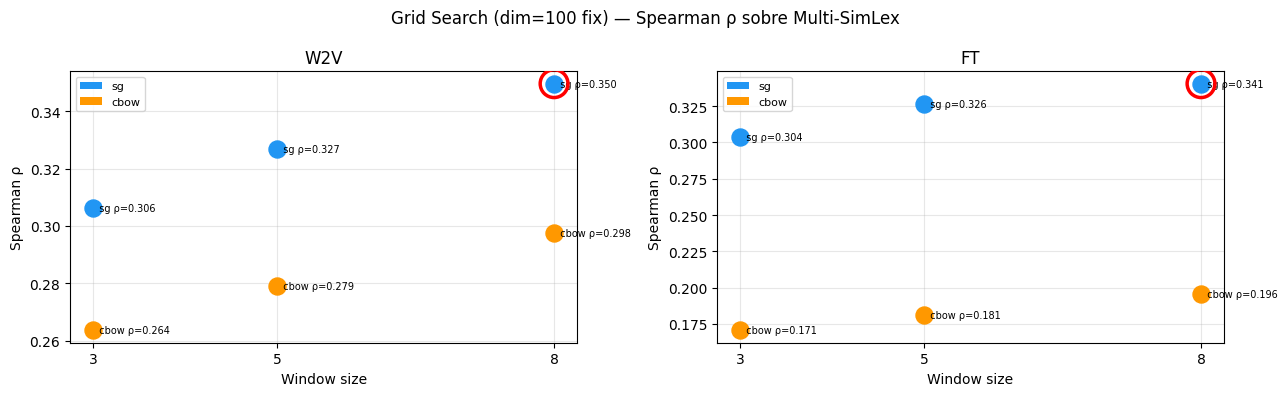

In [85]:


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Grid Search (dim={GRID_DIM} fix) — Spearman ρ sobre Multi-SimLex", fontsize=12)
colors = {"sg": "#2196F3", "cbow": "#FF9800"}

for ax, arch in zip(axes, ["W2V", "FT"]):
    sub = grid_df[grid_df["arch"] == arch].copy()
    for _, row in sub.iterrows():
        ax.scatter(row["window"], row["spearman_rho"],
                    color=colors[row["sg"]], s=150, zorder=3)
        ax.annotate(f"  {row['sg']} ρ={row['spearman_rho']:.3f}",
                    (row["window"], row["spearman_rho"]), fontsize=7, va="center")
    # Marca l'òptim global
    opt = sub[(sub["window"]==BEST_WINDOW) & (sub["sg"]==("sg" if BEST_SG else "cbow"))]
    if not opt.empty:
        ax.scatter(opt["window"], opt["spearman_rho"],
                    s=400, facecolors="none", edgecolors="red", linewidths=2.5,
                    zorder=4, label="Òptim global")
    ax.set_title(arch); ax.set_xlabel("Window size"); ax.set_ylabel("Spearman ρ")
    ax.set_xticks(GRID_WINDOW_OPTS); ax.grid(alpha=0.3)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor=c, label=k) for k,c in colors.items()], fontsize=8)

plt.tight_layout(); plt.show()


### Anàlisi de la cerca d'hiperparàmetres: Word2Vec vs fastText en avaluació intrínseca (Multi-SimLex)

La cerca explora l'efecte combinat de l'arquitectura (Word2Vec vs fastText), la mida de la finestra de context (window = 3, 5, 8) i el mode d'entrenament (Skip-gram vs CBOW) sobre la correlació de Spearman (ρ) en Multi-SimLex. Els dotze experiments produeixen una jerarquia clara:

| Rang | Arquitectura | Window | Mode | Spearman ρ | OOV |
|---|---|---|---|---|---|
| 1 | W2V | 8 | Skip-gram | 0.3496 | 206 |
| 2 | FT | 8 | Skip-gram | 0.3405 | 0 |
| 3 | W2V | 5 | Skip-gram | 0.3267 | 206 |
| 4 | FT | 5 | Skip-gram | 0.3264 | 0 |
| 5 | W2V | 3 | Skip-gram | 0.3063 | 206 |
| 6 | FT | 3 | Skip-gram | 0.3037 | 0 |
| 7 | W2V | 8 | CBOW | 0.2975 | 206 |
| 8 | W2V | 5 | CBOW | 0.2790 | 206 |
| 9 | W2V | 3 | CBOW | 0.2635 | 206 |
| 10 | FT | 8 | CBOW | 0.1957 | 0 |
| 11 | FT | 5 | CBOW | 0.1814 | 0 |
| 12 | FT | 3 | CBOW | 0.1705 | 0 |

**Efecte del mode d'entrenament (Skip-gram vs CBOW).** La diferència entre Skip-gram i CBOW és el factor més impactant, especialment per a fastText. Skip-gram supera CBOW en un 17% per a Word2Vec i en un sorprenent 74% per a fastText. Skip-gram aprèn prediccions fines (donat un token d'entrada, quins tokens apareixen al context?), mentre que CBOW aprèn agregacions (donat el context, quin token apareix al centre?). Skip-gram és més sensible a relacions de similitud subtils entre paraules concretes. Per a fastText el cost de CBOW és especialment alt: el model ha de compondre n-grames per generar la representació d'entrada i, a sobre, operar sobre una representació de context ja agregada, perdent informació en els dos passos.

**Efecte de la mida del context (window).** La correlació de Spearman disminueix de manera monòtona amb finestres més petites: window=8 supera window=3 aproximadament un 14% en Word2Vec i un 12% en fastText. Amb una finestra gran el model veu més context al voltant de cada paraula, la qual cosa li permet capturar relacions semàntiques més subtils. Window=3 és massa restrictiu i tendeix a capturar relacions de coocurrència de baixa semàntica (paraules que simplement van juntes sovint però no són similars) en lloc de similitud real. La literatura recomana window=5 com a valor per defecte per equilibrar semàntica i eficiència, però sobre el corpus de Viquipèdia window=8 resulta clarament superior.

**Efecte de l'arquitectura (Word2Vec vs fastText).** La diferència és la menys important dels tres factors: Word2Vec supera fastText marginalment però de manera consistent (+2.6% a window=8, Skip-gram). Això és contraintuïtiu, perquè fastText té cobertura total (OOV=0) mentre que Word2Vec deixa 206 paraules de Multi-SimLex sense vector. Dos factors ho expliquen: primer, la qualitat dels vectors per a les paraules vistes és més crítica que la cobertura en un dataset d'avaluació intrínseca com Multi-SimLex; segon, la composició de n-grames de fastText pot generar representacions lleugerament menys nítides que un vector entrenat directament per a paraules que el model ha vist moltes vegades.

**Configuració seleccionada: Skip-gram, window=8.** Ambdues arquitectures s'utilitzen amb aquesta configuració per als experiments posteriors. La diferència entre elles és petita (+2.6%) i cau dins de la variabilitat de l'entrenament, de manera que cap dels dos és clarament superior en l'avaluació intrínseca.


In [86]:
CONFIG["best_window"] = BEST_WINDOW
CONFIG["best_sg"]     = BEST_SG
print(f"\nCONFIG actualitzat: best_window={BEST_WINDOW}, best_sg={BEST_SG}")


CONFIG actualitzat: best_window=8, best_sg=1


---
## 6. Entrenament dels models finals

Ara que coneixem la millor configuració (`window=8`, Skip-gram), entrenem els models finals. L'enunciat proposa comparar l'efecte de la dimensionalitat i, com a alternativa, la mida del corpus. Hem decidit fer les dues comparacions de manera independent, mantenint fixos tots els altres paràmetres en cadascuna, per poder atribuir cada diferència de rendiment exclusivament a la variable que s'estudia.

### 6a. Efecte de la dimensionalitat (dim=25, 50, 100)

Entrenem Word2Vec i fastText amb les tres dimensions sobre el **corpus complet**, mantenint `window=8`, Skip-gram i tota la resta de paràmetres constants. Qualsevol diferència de rendiment observada a la Part 2 serà deguda exclusivament a la dimensió dels vectors.

### 6b. Efecte de la mida del corpus

Entrenem el mateix model (dim=100, `window=8`, Skip-gram) amb tres fraccions del corpus: 10%, 50% i el corpus complet (100%). L'objectiu és traçar la corba de rendiments decresents: s'espera que passar de corpus molt petit (10%) a moderat (50%) doni un salt important, i que de 50% a 100% el guany s'estanqui. Amb pocs exemples el model no veu suficient context per aprendre representacions estables; a partir d'un cert punt afegir més dades millora poc perquè els patrons semàntics principals ja han estat vistos.

Els models es desen a disc i es carreguen sense reentrenar en execucions posteriors (`FORCE_RETRAIN_A = False`, `FORCE_RETRAIN_B = False`). L'`EpochLogger` registra el Δ de pèrdua per cada epoch per verificar la convergència.


In [87]:
# ── Dimensions a comparar (6a: efecte dimensionalitat) ───────────────────
# S'utilitza el corpus complet per garantir que les diferències observades
# entre dimensions siguin atribuïbles exclusivament a la dimensió i no a
# una manca de dades d'entrenament.
ALL_DIMS = CONFIG["embedding_dims"]   # [25, 50, 100]


# ── Mides de corpus a comparar (6b: efecte mida corpus) ──────────────────
# Calculem el total de frases del corpus complet per definir els
# subconjunts com a percentatges, de manera que l'experiment s'adapta
# automàticament si es canvia el corpus.
CORPUS_SIZE_DIM = 100
n_total = sum(1 for _ in open(CONFIG["processed_corpus"], encoding="utf-8"))
print(f"Total frases corpus complet: {n_total:,}")

CORPUS_PERCENTAGES = [0.10, 0.50, 1.00]  # 10%, 50%, 100%
CORPUS_SIZES = [int(n_total * p) if p < 1.0 else None
                for p in CORPUS_PERCENTAGES]
CORPUS_SIZE_LABELS = {
    size: f"{int(p*100)}%"
    for size, p in zip(CORPUS_SIZES, CORPUS_PERCENTAGES)
}


# ── Els dos experiments comparteixen la configuració òptima del grid ──────
# window i sg es mantenen fixos a tots dos experiments per no introduir
# variables addicionals que dificultin la interpretació dels resultats.
print("Configuració dels experiments:")
print(f"  6a — Dimensions: {ALL_DIMS}  (corpus complet, window={CONFIG['best_window']}, sg={CONFIG['best_sg']})")
print(f"  6b — Mides corpus: {[CORPUS_SIZE_LABELS[s] for s in CORPUS_SIZES]}  "
      f"({[s if s else 'complet' for s in CORPUS_SIZES]} frases)  (dim={CORPUS_SIZE_DIM})")


Total frases corpus complet: 5,461,482
Configuració dels experiments:
  6a — Dimensions: [25, 50, 100]  (corpus complet, window=8, sg=1)
  6b — Mides corpus: ['10%', '50%', '100%']  ([546148, 2730741, 'complet'] frases)  (dim=100)


In [88]:
from gensim.models.callbacks import CallbackAny2Vec
from scipy.stats import spearmanr


# ── Callback de pèrdua per època ─────────────────────────────────────────
class EpochLogger(CallbackAny2Vec):
    """
    Registra la pèrdua acumulada i el delta per època.
    Si simlex_df no és None, avalua també el Spearman de Multi-SimLex
    a cada época (útil per verificar convergència).
    """
    def __init__(self, label: str, simlex_df=None):
        self.label     = label
        self.epoch     = 0
        self._prev     = 0
        self.simlex_df = simlex_df
        self.history   = []  # [(loss, delta, rho)]

    def on_epoch_end(self, model):
        self.epoch += 1
        loss  = model.get_latest_training_loss()
        delta = loss - self._prev
        self._prev = loss

        rho     = float("nan")
        rho_str = ""
        if self.simlex_df is not None:
            rho, _ = eval_simlex(model.wv, self.simlex_df)
            rho_str = f"  ρ={rho:.4f}"

        self.history.append((loss, delta, rho))
        print(f"  [{self.label}] Època {self.epoch}/{CONFIG['epochs']}  "
              f"loss={loss:.0f}  Δ={delta:.0f}{rho_str}")


def _model_name(arch: str, dim: int, corpus_path: str,
                window: int, sg: int, min_count: int) -> str:
    """
    Nom canònic del model que inclou tots els hiperparàmetres rellevants.
    Dos models amb els mateixos paràmetres compartiran el mateix fitxer,
    evitant reentrenaments i duplicats en disc.
    Format: {arch}_w{window}_{sg}_mc{min_count}_d{dim}_{corpus_tag}
    """
    sg_tag     = "sg" if sg else "cbow"
    corpus_tag = Path(corpus_path).stem
    return f"{arch}_w{window}_{sg_tag}_mc{min_count}_d{dim}_{corpus_tag}"


def train_word2vec(dim: int, corpus_path: str,
                   force_retrain: bool = False,
                   eval_epochs: bool = False) -> Word2Vec:
    """
    Entrena o carrega W2V amb nom canònic basat en tots els hiperparàmetres.
    Si eval_epochs=True avalua el Spearman de Multi-SimLex a cada època;
    activar només en un model representatiu per verificar convergència.
    """
    name       = _model_name("w2v", dim, corpus_path,
                             CONFIG["best_window"], CONFIG["best_sg"],
                             CONFIG["min_count"])
    model_path = Path(CONFIG["models_dir"]) / f"{name}.model"

    if model_path.exists() and not force_retrain:
        print(f"[OK] Carregant W2V des de {model_path.name}")
        return Word2Vec.load(str(model_path))

    simlex = _simlex_df if eval_epochs else None
    cb     = EpochLogger(name, simlex_df=simlex)
    print(f"\n── Entrenant W2V {name} ──")
    model = Word2Vec(
        sentences=SentenceIterator(corpus_path),
        vector_size=dim,
        window=CONFIG["best_window"], min_count=CONFIG["min_count"],
        workers=CONFIG["workers"],    epochs=CONFIG["epochs"],
        sg=CONFIG["best_sg"],         seed=CONFIG["seed"],
        compute_loss=True,            callbacks=[cb],
    )
    model.save(str(model_path))
    print(f"[OK] Guardat: {model_path.name}")
    return model


def train_fasttext(dim: int, corpus_path: str,
                   force_retrain: bool = False) -> GensimFastText:
    """
    Entrena o carrega FT (gensim) amb nom canònic basat en tots els hiperparàmetres.
    El model de corpus complet amb dim=100 es reutilitza automàticament
    entre l'experiment 6a i el punt 100% de l'experiment 6b.
    """
    name       = _model_name("ft", dim, corpus_path,
                             CONFIG["best_window"], CONFIG["best_sg"],
                             CONFIG["min_count"])
    model_path = Path(CONFIG["models_dir"]) / f"{name}.model"

    if model_path.exists() and not force_retrain:
        print(f"[OK] Carregant FT des de {model_path.name}")
        return GensimFastText.load(str(model_path))

    print(f"\n── Entrenant FT {name} ──")
    model = GensimFastText(
        sentences=SentenceIterator(corpus_path),
        vector_size=dim,
        window=CONFIG["best_window"], min_count=CONFIG["min_count"],
        workers=CONFIG["workers"],    epochs=CONFIG["epochs"],
        sg=CONFIG["best_sg"],         seed=CONFIG["seed"],
    )
    model.save(str(model_path))
    print(f"[OK] Guardat: {model_path.name}")
    return model


def get_or_build_corpus_subset(max_sentences, label: str) -> str:
    """Construeix (si cal) un subcorpus de mida limitada. Retorna la ruta."""
    if max_sentences is None:
        return CONFIG["processed_corpus"]
    path = f"data/corpus_{label}.txt"
    if not Path(path).exists():
        build_processed_corpus(corpus_files, path,
                               max_sentences=max_sentences,
                               force_rebuild=True)
    return path


In [89]:
FORCE_RETRAIN_A = False  # True per forçar reentrenament

# ── 6a: models per dimensió (corpus complet) ─────────────────────────────
print("\n" + "═"*60)
print("6a — Entrenament per DIMENSIÓ (corpus complet)")
print("═"*60)

W2V_MODELS: Dict[str, Word2Vec]       = {}
FT_MODELS:  Dict[str, GensimFastText] = {}

for dim in ALL_DIMS:
    # eval_epochs=True només per al model més gran (dim=100) per verificar
    # convergència. Si el model amb més paràmetres convergeix en 5 epochs,
    # els models de dimensions menors (25, 50) convergiran encara més ràpid.
    eval_ep = (dim == max(ALL_DIMS))
    W2V_MODELS[f"w2v_{dim}"] = train_word2vec(
        dim, CONFIG["processed_corpus"],
        force_retrain=FORCE_RETRAIN_A, eval_epochs=eval_ep)
    FT_MODELS[f"ft_{dim}"] = train_fasttext(
        dim, CONFIG["processed_corpus"],
        force_retrain=FORCE_RETRAIN_A)

print("\nModels per dimensió:", list(W2V_MODELS.keys()) + list(FT_MODELS.keys()))



════════════════════════════════════════════════════════════
6a — Entrenament per DIMENSIÓ (corpus complet)
════════════════════════════════════════════════════════════
[OK] Carregant W2V des de w2v_w8_sg_mc5_d25_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d25_corpus_processed.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d50_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d50_corpus_processed.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_processed.model

Models per dimensió: ['w2v_25', 'w2v_50', 'w2v_100', 'ft_25', 'ft_50', 'ft_100']


In [90]:
FORCE_RETRAIN_B = False  # True per forçar reentrenament

# ── 6b: models per mida de corpus (dim=100 fixa) ─────────────────────────
print("\n" + "═"*60)
print(f"6b — Entrenament per MIDA DE CORPUS (dim={CORPUS_SIZE_DIM})")
print("═"*60)
print("Nota: el model de corpus complet amb dim=100 es reutilitza de 6a")
print("      si els hiperparàmetres coincideixen (nom canònic idèntic).\n")

W2V_CORPUS: Dict[str, Word2Vec]       = {}
FT_CORPUS:  Dict[str, GensimFastText] = {}

for size, label in CORPUS_SIZE_LABELS.items():
    corpus_path = get_or_build_corpus_subset(size, label)
    W2V_CORPUS[f"w2v_{label}"] = train_word2vec(
        CORPUS_SIZE_DIM, corpus_path, force_retrain=FORCE_RETRAIN_B)
    FT_CORPUS[f"ft_{label}"]   = train_fasttext(
        CORPUS_SIZE_DIM, corpus_path, force_retrain=FORCE_RETRAIN_B)

print("\nModels per mida corpus:", list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys()))



════════════════════════════════════════════════════════════
6b — Entrenament per MIDA DE CORPUS (dim=100)
════════════════════════════════════════════════════════════
Nota: el model de corpus complet amb dim=100 es reutilitza de 6a
      si els hiperparàmetres coincideixen (nom canònic idèntic).

[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_10%.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_10%.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_50%.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_50%.model
[OK] Carregant W2V des de w2v_w8_sg_mc5_d100_corpus_processed.model
[OK] Carregant FT des de ft_w8_sg_mc5_d100_corpus_processed.model

Models per mida corpus: ['w2v_10%', 'w2v_50%', 'w2v_100%', 'ft_10%', 'ft_50%', 'ft_100%']


---
## 7. Càrrega del fastText oficial (Facebook)

El model oficial `cc.es.300.bin` (300 dimensions, entrenat sobre Common Crawl) s'usa com a **referència externa** a la Part 2. Serveix per respondre a la pregunta de l'enunciat sobre la diferència entre un model entrenat «a casa» i un model industrial preentrenat: el model oficial ha vist ordres de magnitud més dades (Common Crawl és molt més gran que la Viquipèdia), fa servir 300 dimensions en lloc de les nostres 100, i ha estat optimitzat per Facebook Research.

Es fa servir el format `.bin` (no el `.vec`) perquè conté els n-grames de caràcters interns del model, necessaris per generar vectors de paraules OOV: és el principal avantatge de fastText sobre Word2Vec. Es carrega amb `gensim.models.fasttext.load_facebook_model`, que llegeix el `.bin` directament sense paquets addicionals. Per la seva mida (~7 GB) s'ha descarregat a part i es deixa a `models/cc.es.300.bin`. Si no hi és, `FT_OFFICIAL` val `None` i les parts posteriors ho gestionen sense fallar.


In [91]:
# ── Càrrega del fastText oficial (Facebook) ───────────────────────────────
# S'utilitza el fitxer .bin (i no el .vec) perquè conté els n-grames de
# caràcters interns del model. Això permet generar vectors per a paraules
# OOV mitjançant composició de subparaules, que és el principal avantatge
# de fastText respecte a Word2Vec. El fitxer .vec és un subconjunt del .bin
# que només conté els vectors del vocabulari vist; no suporta OOV.
#
# Descàrrega (terminal):
#   wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz
#   gunzip cc.es.300.bin.gz            (Linux/Mac)
#   python -c "import gzip,shutil; shutil.copyfileobj(gzip.open('cc.es.300.bin.gz','rb'), open('cc.es.300.bin','wb'))"   (Windows)

import gensim

FT_OFFICIAL_PATH = CONFIG["fasttext_official_path"]

FT_OFFICIAL = None
if Path(FT_OFFICIAL_PATH).exists():
    print(f"Carregant fastText oficial: {FT_OFFICIAL_PATH} ...")
    FT_OFFICIAL = gensim.models.fasttext.load_facebook_model(FT_OFFICIAL_PATH)
    print(f"[OK] dim={FT_OFFICIAL.vector_size}  vocab={len(FT_OFFICIAL.wv):,}")
else:
    print(f"[AVÍS] Model oficial no trobat a: {FT_OFFICIAL_PATH}")
    print("       Descàrrega:")
    print("         wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz")
    print("         (descomprimir) i deixar-lo a models/cc.es.300.bin")


Carregant fastText oficial: models/cc.es.300.bin ...
[OK] dim=300  vocab=2,000,000


---
## 8. Resum i verificació dels models

Abans de passar a les avaluacions formals, fem dues comprovacions. Primer, una taula que recull tots els models entrenats amb la seva mida en disc i el nombre de paràmetres, per tenir una idea del cost computacional de cadascun. Segon, una verificació ràpida de similituds cosinus sobre tres parells semàntics canònics (rey–reina, perro–gato, madrid–barcelona), que serveix de *sanity check*: si els models estan ben entrenats, tots aquests parells haurien de tenir similituds altes (>0.6), i els parells taxonòmics o geogràfics haurien de puntuar més que els relacionals.


In [92]:
def _model_file_size_mb(arch: str, dim: int, corpus_path: str) -> float:
    """
    Mida total en MB de tots els fitxers (shards de gensim inclosos) d'un
    model, reconstruint el nom canònic exacte amb _model_name.
    """
    name = _model_name(arch, dim, corpus_path,
                       CONFIG["best_window"], CONFIG["best_sg"],
                       CONFIG["min_count"])
    base = Path(CONFIG["models_dir"])
    return sum(f.stat().st_size for f in base.glob(f"{name}.model*")
               if f.is_file()) / 1e6


print("=" * 70)
print("MODELS ENTRENATS")
print(f"  Hiperparàmetres fixes: window={CONFIG['best_window']}, "
      f"sg={CONFIG['best_sg']} ({'Skip-gram' if CONFIG['best_sg'] else 'CBOW'})")
print("=" * 70)

all_models_info = []

# ── 6a: models per dimensió (corpus complet) ─────────────────────────────
print("\n── 6a: Models per dimensió (corpus complet) ──")
print(f"{'Clau':<18} {'Tipus':<22} {'Dim':>5} {'Vocab':>12} {'MB':>8}")
print("-" * 67)
for key, model in {**W2V_MODELS, **FT_MODELS}.items():
    dim    = model.vector_size
    vocab  = len(model.wv)
    arch_k = "w2v" if key.startswith("w") else "ft"
    arch   = "Word2Vec" if arch_k == "w2v" else "fastText (gensim)"
    size   = _model_file_size_mb(arch_k, dim, CONFIG["processed_corpus"])
    print(f"{key:<18} {arch:<22} {dim:>5} {vocab:>12,} {size:>7.1f}")
    all_models_info.append((key, arch, dim, vocab, size))

# ── 6b: models per mida de corpus (dim=100) ──────────────────────────────
print("\n── 6b: Models per mida de corpus (dim=100) ──")
print(f"{'Clau':<18} {'Tipus':<22} {'Dim':>5} {'Vocab':>12} {'MB':>8}")
print("-" * 67)
_label_to_path = {}
for size_s, label in CORPUS_SIZE_LABELS.items():
    _label_to_path[label] = (CONFIG["processed_corpus"] if size_s is None
                             else f"data/corpus_{label}.txt")

for key, model in {**W2V_CORPUS, **FT_CORPUS}.items():
    dim    = model.vector_size
    vocab  = len(model.wv)
    arch_k = "w2v" if key.startswith("w") else "ft"
    arch   = "Word2Vec" if arch_k == "w2v" else "fastText (gensim)"
    label  = key.split("_", 1)[1]
    cpath  = _label_to_path.get(label, CONFIG["processed_corpus"])
    size   = _model_file_size_mb(arch_k, dim, cpath)
    print(f"{key:<18} {arch:<22} {dim:>5} {vocab:>12,} {size:>7.1f}")

# ── fastText oficial (referència externa) ────────────────────────────────
if FT_OFFICIAL is not None:
    dim_ = (FT_OFFICIAL.get_dimension() if hasattr(FT_OFFICIAL, "get_dimension")
            else FT_OFFICIAL.vector_size)
    poff = Path(CONFIG["fasttext_official_path"])
    sz   = (poff.stat().st_size if poff.exists()
            else poff.with_suffix(".vec").stat().st_size
            if poff.with_suffix(".vec").exists() else 0) / 1e6
    print("\n── fastText oficial (referència externa) ──")
    print(f"{'ft_official':<18} {'fastText oficial':<22} {dim_:>5} {'—':>12} {sz:>7.1f}")


MODELS ENTRENATS
  Hiperparàmetres fixes: window=8, sg=1 (Skip-gram)

── 6a: Models per dimensió (corpus complet) ──
Clau               Tipus                    Dim        Vocab       MB
-------------------------------------------------------------------
w2v_25             Word2Vec                  25      300,250    69.9
w2v_50             Word2Vec                  50      300,250   130.0
w2v_100            Word2Vec                 100      300,250   250.1
ft_25              fastText (gensim)         25      300,250   269.9
ft_50              fastText (gensim)         50      300,250   530.0
ft_100             fastText (gensim)        100      300,250  1050.1

── 6b: Models per mida de corpus (dim=100) ──
Clau               Tipus                    Dim        Vocab       MB
-------------------------------------------------------------------
w2v_10%            Word2Vec                 100       74,229    61.7
w2v_50%            Word2Vec                 100      197,537   164.5
w2v_100%

#### Verificació ràpida: similitud cosinus dels models entrenats

Calculem la similitud cosinus per a tres parells semàntics exemplars que permeten comprovar que els models capturen relacions bàsiques del tipus correcte. El parell *rey–reina* representa una relació de gènere gramatical, *perro–gato* una relació taxonòmica (animals domèstics de la mateixa categoria), i *madrid–barcelona* una relació geogràfica (ciutats espanyoles). S'espera que tots els valors siguin alts i que els parells taxonòmics i geogràfics puntuin lleugerament per sobre dels relacionals.


  Model              Par   Sim
 w2v_25        rey—reina 0.836
 w2v_25       perro—gato 0.931
 w2v_25 madrid—barcelona 0.933
 w2v_50        rey—reina 0.772
 w2v_50       perro—gato 0.910
 w2v_50 madrid—barcelona 0.904
w2v_100        rey—reina 0.693
w2v_100       perro—gato 0.815
w2v_100 madrid—barcelona 0.788
  ft_25        rey—reina 0.851
  ft_25       perro—gato 0.940
  ft_25 madrid—barcelona 0.933
  ft_50        rey—reina 0.825
  ft_50       perro—gato 0.905
  ft_50 madrid—barcelona 0.906
 ft_100        rey—reina 0.745
 ft_100       perro—gato 0.851
 ft_100 madrid—barcelona 0.803


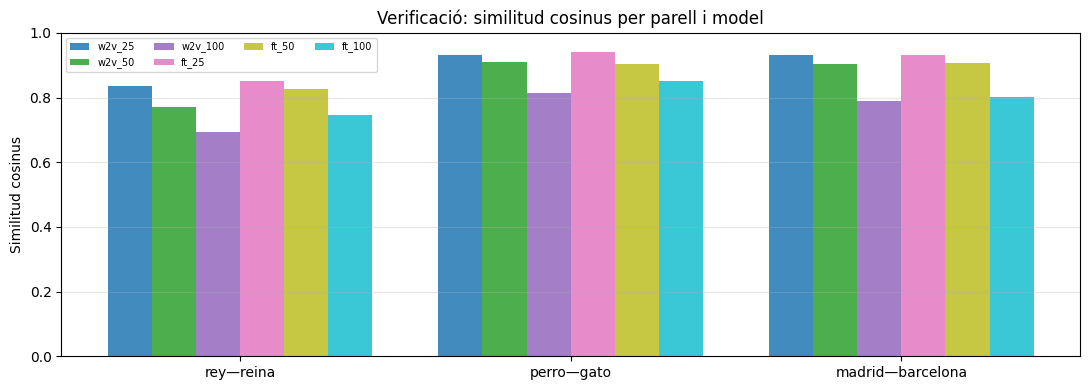

In [93]:
# ── Test de similituds ────────────────────────────────────────────────────
TEST_WORDS = [("rey", "reina"), ("perro", "gato"), ("madrid", "barcelona")]
rows = []
for key, model in {**W2V_MODELS, **FT_MODELS}.items():
    for w1, w2 in TEST_WORDS:
        try:
            sim = model.wv.similarity(w1, w2)
            rows.append({"Model": key, "Par": f"{w1}—{w2}", "Sim": round(sim, 3)})
        except KeyError:
            rows.append({"Model": key, "Par": f"{w1}—{w2}", "Sim": "OOV"})

sim_df = pd.DataFrame(rows)
print(sim_df.to_string(index=False))

plot_df = sim_df[sim_df["Sim"] != "OOV"].copy()
plot_df["Sim"] = plot_df["Sim"].astype(float)
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    models_list = list({**W2V_MODELS, **FT_MODELS}.keys())
    x = np.arange(len(TEST_WORDS))
    width = 0.8 / len(models_list)
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_list)))
    for i, (key, color) in enumerate(zip(models_list, colors)):
        vals = []
        for w1, w2 in TEST_WORDS:
            r = plot_df[(plot_df["Model"]==key) & (plot_df["Par"]==f"{w1}—{w2}")]
            vals.append(r["Sim"].values[0] if not r.empty else 0)
        ax.bar(x + i*width - 0.4 + width/2, vals, width, label=key, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f"{w1}—{w2}" for w1,w2 in TEST_WORDS])
    ax.set_ylabel("Similitud cosinus"); ax.set_ylim(0,1)
    ax.set_title("Verificació: similitud cosinus per parell i model")
    ax.legend(fontsize=7, ncol=4); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()


#### Resultats de la verificació

| Model | rey—reina | perro—gato | madrid—barcelona |
|---|---|---|---|
| w2v_25 | 0.836 | 0.931 | 0.933 |
| w2v_50 | 0.772 | 0.910 | 0.904 |
| w2v_100 | 0.693 | 0.815 | 0.788 |
| ft_25 | 0.851 | 0.940 | 0.933 |
| ft_50 | 0.825 | 0.905 | 0.906 |
| ft_100 | 0.745 | 0.851 | 0.803 |

Tots els valors són alts (>0.69), cosa que confirma que els models han après representacions semànticament coherents. El parell *perro–gato* és el que obté similituds més altes de manera consistent en tots els models, segurament perquè els dos animals apareixen sovint en contextos molt similars a la Viquipèdia. *Rey–reina* puntua lleugerament menys, probablement perquè la relació de gènere és més subtil i depèn d'un context lingüístic específic.

Un fet interessant és que els models de 25 dimensions donen similituds més altes en termes absoluts que els de 100 dimensions. Això no vol dir que siguin millors: la similitud cosinus mesura escala absoluta, però la correlació de Spearman (que és la mètrica oficial de Multi-SimLex) mesura si el *rànquing* relatiu entre parells és correcte. Un model de 100 dimensions pot ordenar millor els parells de paraules malgrat que els valors absoluts siguin menys extrems. Aquesta distinció es confirma a la Part 2.


---
## 9. Funcions d'accés als embeddings

Definim un conjunt de funcions auxiliars que encapsulen l'accés als vectors i la construcció de la matriu d'embeddings per al model seqüencial. Com que tota la pràctica viu en un únic notebook, no cal cap mecanisme d'importació entre fitxers: les Parts 2 i 3 criden directament aquestes funcions i reutilitzen les variables globals ja definides (`W2V_MODELS`, `FT_MODELS`, `FT_OFFICIAL`, etc.).

La funció `get_word_vector` unifica l'accés als models de Gensim (Word2Vec i fastText entrenats) i al fastText oficial, gestionant els casos OOV de manera diferent per a cada arquitectura: Word2Vec retorna `None` per a paraules no vistes, fastText (gràcies als n-grames de caràcters) sempre pot retornar un vector aproximat. La funció `get_sentence_vector` agrega els vectors de paraules en un vector de frase, admetent tant la mitjana simple com la ponderació per TF-IDF. Finalment, `build_embedding_matrix` construeix la matriu de vectors indexada pel vocabulari del corpus STS, necessària per inicialitzar la capa d'embedding del model seqüencial siamès.


In [94]:
def get_word_vector(word: str, model_key: str) -> Optional[np.ndarray]:
    """
    Retorna el vector d'una paraula per a un model determinat.
    model_key: 'w2v_25','w2v_50','w2v_100','ft_25','ft_50','ft_100','ft_official'
    Retorna None si la paraula no es troba (W2V OOV).
    """
    if model_key == "ft_official":
        if FT_OFFICIAL is None:
            return None
        # load_facebook_model retorna un objecte FastText de gensim amb .wv,
        # que genera vectors per a paraules OOV a partir dels n-grames de
        # caràcters (mai falla en retornar un vector).
        return FT_OFFICIAL.wv.get_vector(word, norm=False).astype(np.float32)

    if model_key in W2V_MODELS:
        m = W2V_MODELS[model_key]
        return m.wv[word] if word in m.wv else None

    if model_key in FT_MODELS:
        return FT_MODELS[model_key].wv.get_vector(word, norm=False)

    if model_key in W2V_CORPUS:
        m = W2V_CORPUS[model_key]
        return m.wv[word] if word in m.wv else None

    if model_key in FT_CORPUS:
        return FT_CORPUS[model_key].wv.get_vector(word, norm=False)

    raise ValueError(f"Model desconegut: '{model_key}'. "
                     f"Opcions: {list(W2V_MODELS) + list(FT_MODELS) + list(W2V_CORPUS) + list(FT_CORPUS) + ['ft_official']}")


def get_sentence_vector(
    tokens: List[str],
    model_key: str,
    weights: Optional[np.ndarray] = None,
) -> Optional[np.ndarray]:
    """
    Representa una frase com la mitjana (simple o ponderada amb TF-IDF) dels seus vectors.
    """
    vecs, ws = [], []
    for i, token in enumerate(tokens):
        v = get_word_vector(token, model_key)
        if v is not None:
            vecs.append(v)
            ws.append(weights[i] if weights is not None else 1.0)
    if not vecs:
        return None
    vecs_arr = np.array(vecs)
    ws_arr   = np.array(ws, dtype=np.float32).reshape(-1, 1)
    ws_arr   = ws_arr / (ws_arr.sum() + 1e-9)
    return (vecs_arr * ws_arr).sum(axis=0)


def build_embedding_matrix(
    vocab: Dict[str, int],
    model_key: str,
    dim: int,
) -> np.ndarray:
    """
    Construeix la matriu d'embeddings per al model siamès BiLSTM (Part 3).
    Índex 0 → <PAD>, Índex 1 → <UNK>.
    """
    rng    = np.random.default_rng(CONFIG["seed"])
    matrix = np.zeros((len(vocab), dim), dtype=np.float32)
    matrix[1] = rng.normal(scale=0.01, size=dim)

    n_found, n_oov = 0, 0
    for word, idx in vocab.items():
        if idx <= 1:
            continue
        v = get_word_vector(word, model_key)
        if v is not None:
            matrix[idx] = v
            n_found += 1
        else:
            matrix[idx] = rng.normal(scale=0.01, size=dim)
            n_oov += 1

    coverage = n_found / (n_found + n_oov + 1e-9)
    print(f"[{model_key}] Matriu embeddings: {matrix.shape}  "
          f"cobertura={coverage:.1%}  OOV={n_oov:,}")
    return matrix


def is_oov(word: str, model_key: str) -> bool:
    # OOV = la paraula NO és al vocabulari après pel model.
    # IMPORTANT: per a fastText, ser OOV no vol dir que no es pugui obtenir un
    # vector — fastText sempre en composa un a partir dels n-grames de caràcters.
    # Però per fer una comparació justa amb Word2Vec, aquí mesurem la pertinença
    # al vocabulari (key_to_index), igual per a tots dos tipus de model.
    if model_key in W2V_MODELS:
        return word not in W2V_MODELS[model_key].wv.key_to_index
    if model_key in W2V_CORPUS:
        return word not in W2V_CORPUS[model_key].wv.key_to_index
    if model_key in FT_MODELS:
        return word not in FT_MODELS[model_key].wv.key_to_index
    if model_key in FT_CORPUS:
        return word not in FT_CORPUS[model_key].wv.key_to_index
    if model_key == "ft_official":
        if FT_OFFICIAL is None:
            return True
        return word not in FT_OFFICIAL.wv.key_to_index
    raise ValueError(f"Model desconegut: {model_key}")


# ── Prova ─────────────────────────────────────────────────────────────────
print("Prova get_word_vector:")
v = get_word_vector("gato", "w2v_100")
print(f"  'gato' w2v_100 → {v[:5] if v is not None else 'OOV'}...")

print("\nProva get_sentence_vector:")
sv = get_sentence_vector(["el", "gato", "come"], "ft_100")
print(f"  'el gato come' ft_100 → {sv[:5] if sv is not None else 'Error'}...")

print("\nFuncions d'accés als embeddings llestes.")


Prova get_word_vector:
  'gato' w2v_100 → [ 0.10570432  0.03614071  0.11962759  0.12293452 -0.25332263]...

Prova get_sentence_vector:
  'el gato come' ft_100 → [ 0.13889748  0.17780888  0.3453189  -0.01238065  0.37309027]...

Funcions d'accés als embeddings llestes.


---
### Resum de les variables i funcions compartides

Les parts 2 i 3 reutilitzen directament els objectes i funcions següents, ja definits en memòria:

| Variable / Funció | Tipus | Descripció |
|---|---|---|
| `CONFIG` | `dict` | Configuració global de la pràctica |
| `W2V_MODELS` | `dict[str, Word2Vec]` | Models Word2Vec per dimensió: `w2v_25`, `w2v_50`, `w2v_100` |
| `FT_MODELS` | `dict[str, GensimFastText]` | Models fastText (gensim) per dimensió: `ft_25`, `ft_50`, `ft_100` |
| `W2V_CORPUS`, `FT_CORPUS` | `dict` | Models per mida de corpus (`10%`, `50%`, `100%`) |
| `FT_OFFICIAL` | model o `None` | fastText oficial de Facebook (300d, Common Crawl) |
| `get_word_vector(word, model_key)` | funció | Vector d'una paraula per a un model determinat |
| `get_sentence_vector(tokens, model_key, weights?)` | funció | Vector agregat d'una frase (mitjana simple o ponderada per TF-IDF) |
| `build_embedding_matrix(vocab, model_key, dim)` | funció | Matriu d'embeddings pre-inicialitzada per al model BiLSTM |
| `is_oov(word, model_key)` | funció | Comprova si una paraula és fora del vocabulari del model |


---
---
# Part 2: Avaluació Intrínseca (Multi-SimLex)

L'avaluació intrínseca mesura directament la qualitat dels embeddings com a representacions de paraules aïllades, sense cap tasca de baixa corrient: per a cada parell de paraules del dataset calculem la similitud cosinus entre els seus vectors i comparem el rànquing resultant amb el judici humà de similitud mitjançant la correlació de Spearman (ρ). Com més alta sigui ρ, millor capta el model la intuïció humana sobre quines paraules s'assemblen semànticament.

Els models que avaluem són: Word2Vec i fastText entrenats sobre la Viquipèdia amb tres dimensions (25, 50, 100) i tres mides de corpus (10%, 50%, 100%), més el fastText oficial de Facebook (300d, Common Crawl) com a referència externa.

## Índex Part 2
1. Funció d'avaluació intrínseca
2. Avaluació de tots els models
3. Anàlisi OOV
4. Taula de resultats i gràfics


---
### P2-2. Funció d'avaluació intrínseca

La funció d'avaluació rep un model i el dataset Multi-SimLex i retorna la correlació de Spearman entre les similituds cosinus predites i les puntuacions humanes. Per a cada parell de paraules s'obté el vector corresponent de cada model; si alguna de les paraules no té vector (cas OOV per a Word2Vec), el parell s'exclou del càlcul i es comptabilitza com a perdut. La similitud cosinus es calcula com el producte escalar normalitzat dels dos vectors. Finalment, la correlació de Spearman s'aplica sobre tots els parells per als quals existien ambdós vectors.

Excloure els parells OOV és la convenció estàndard en l'avaluació de word embeddings: incloure-hi un vector zero (l'únic alternatiu possible) inflaria artificialment els valors i faria la comparació entre models injusta.


In [95]:
from scipy.stats import spearmanr
from numpy.linalg import norm as np_norm

def cosine_sim_np(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = np_norm(a), np_norm(b)
    if na < 1e-10 or nb < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def evaluate_intrinsic(
    model_key: str,
    df: pd.DataFrame,
) -> Dict:
    """
    Avalua un model sobre Multi-SimLex.
    Retorna un diccionari amb: model, spearman_rho, n_pairs, n_oov, oov_ratio.
    """
    if df is None or df.empty:
        return {"model": model_key, "spearman_rho": float("nan"),
                "n_pairs": 0, "n_oov": 0, "oov_ratio": float("nan")}

    preds, golds, oov_pairs = [], [], 0
    oov_words = set()

    for _, row in df.iterrows():
        w1, w2, gold = row["word1"], row["word2"], row["score"]
        v1 = get_word_vector(w1, model_key)
        v2 = get_word_vector(w2, model_key)

        if v1 is None or v2 is None:
            oov_pairs += 1
            if v1 is None: oov_words.add(w1)
            if v2 is None: oov_words.add(w2)
            continue

        preds.append(cosine_sim_np(v1, v2))
        golds.append(gold)

    n_total = len(df)
    oov_ratio = oov_pairs / n_total if n_total > 0 else 0

    if len(preds) < 5:
        rho = float("nan")
    else:
        rho, _ = spearmanr(golds, preds)

    return {
        "model"       : model_key,
        "spearman_rho": round(rho, 4) if not np.isnan(rho) else float("nan"),
        "n_pairs"     : len(preds),
        "n_oov"       : oov_pairs,
        "oov_ratio"   : round(oov_ratio, 3),
    }


---
### P2-3. Avaluació de tots els models

La cel·la que segueix aplica la funció d'avaluació a tots els models disponibles: els sis models per dimensió (w2v_25, w2v_50, w2v_100, ft_25, ft_50, ft_100), els sis models per mida de corpus (w2v_10%, w2v_50%, w2v_100%, ft_10%, ft_50%, ft_100%), i el fastText oficial quan és disponible. Els resultats s'acumulen en un DataFrame que s'usa tant per a la taula resum com per als gràfics posteriors.


In [96]:
# ── Llista de models a avaluar ───────────────────────────────────────────
# Incloem tant els models per dimensió com els de mida de corpus
models_to_eval = list(W2V_MODELS.keys()) + list(FT_MODELS.keys())
models_to_eval += list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys())
if FT_OFFICIAL is not None:
    models_to_eval.append("ft_official")

print(f"Avaluant {len(models_to_eval)} models sobre Multi-SimLex...")

intrinsic_results = []
for key in tqdm(models_to_eval, desc="Avaluació intrínseca"):
    res = evaluate_intrinsic(key, simlex_df)
    intrinsic_results.append(res)
    status = f"ρ={res['spearman_rho']:.4f}" if not np.isnan(res['spearman_rho']) else "N/A"
    print(f"  {key:<22}: {status}  OOV={res['oov_ratio']:.1%}")

intrinsic_df = pd.DataFrame(intrinsic_results).sort_values("spearman_rho", ascending=False)


Avaluant 13 models sobre Multi-SimLex...


Avaluació intrínseca:   8%|▊         | 1/13 [00:00<00:05,  2.19it/s]

  w2v_25                : ρ=0.3503  OOV=6.4%


Avaluació intrínseca:  15%|█▌        | 2/13 [00:00<00:04,  2.42it/s]

  w2v_50                : ρ=0.3737  OOV=6.4%


...

  ft_50%                : ρ=0.3648  OOV=0.0%


Avaluació intrínseca:  92%|█████████▏| 12/13 [00:10<00:01,  1.15s/it]

  ft_100%               : ρ=0.3836  OOV=0.0%


Avaluació intrínseca: 100%|██████████| 13/13 [00:10<00:00,  1.20it/s]

  ft_official           : ρ=0.5034  OOV=0.0%


---
### P2-4. Anàlisi OOV

La cel·la que segueix analitza detalladament quines paraules del vocabulari de Multi-SimLex no estan cobertes per cada model. L'anàlisi és útil per dos motius: primer, permet quantificar el cost real de la falta de cobertura de Word2Vec respecte de fastText; segon, identificar el tipus de paraules OOV revela si la causa és estructural (paraules rares per naturalesa) o un problema de corpus (paraules comunes que no arriben al mínim de freqüència).


In [97]:
# ── Anàlisi detallada de les paraules OOV ────────────────────────────────
if simlex_df is not None:
    all_words = set(simlex_df["word1"].tolist() + simlex_df["word2"].tolist())
    print(f"Vocabulari de Multi-SimLex: {len(all_words)} paraules úniques\n")

    # Diccionari unificat de tots els models per obtenir vocab_size
    _all_models = {**W2V_MODELS, **FT_MODELS, **W2V_CORPUS, **FT_CORPUS}

    oov_table = []
    for key in models_to_eval:
        oov_words = [w for w in all_words if is_oov(w, key)]
        if key in _all_models:
            vocab_size = len(_all_models[key].wv)
        elif key == "ft_official" and FT_OFFICIAL is not None:
            vocab_size = len(FT_OFFICIAL.wv)
        else:
            vocab_size = "—"
        oov_table.append({
            "model"       : key,
            "vocab_size"  : vocab_size,
            "oov_count"   : len(oov_words),
            "oov_pct"     : f"{len(oov_words)/len(all_words):.1%}",
            "oov_examples": ", ".join(oov_words[:5]) if oov_words else "cap",
        })

    oov_df = pd.DataFrame(oov_table)
    print("Anàlisi OOV:")
    print(oov_df.to_string(index=False))
    print()
    print("[INFO] OOV = paraula fora del vocabulari après pel model.")
    print("       fastText TÉ paraules OOV igual que Word2Vec, però a diferència")
    print("       d'aquest pot generar-ne un vector compost amb n-grames de")
    print("       caràcters, de manera que mai falla en retornar un vector.")


Vocabulari de Multi-SimLex: 2062 paraules úniques

Anàlisi OOV:
      model  vocab_size  oov_count oov_pct                                                        oov_examples
     w2v_25      300250         93    4.5%     diferir de, darse cuenta de, apurarse, barco de cañón, no usado
     w2v_50      300250         93    4.5%     diferir de, darse cuenta de, apurarse, barco de cañón, no usado
    w2v_100      300250         93    4.5%     diferir de, darse cuenta de, apurarse, barco de cañón, no usado
      ft_25      300250         93    4.5%     diferir de, darse cuenta de, apurarse, barco de cañón, no usado
      ft_50      300250         93    4.5%     diferir de, darse cuenta de, apurarse, barco de cañón, no usado
     ft_100      300250         93    4.5%     diferir de, darse cuenta de, apurarse, barco de cañón, no usado
    w2v_10%       74229        223   10.8%    diferir de, darse cuenta de, apurarse, desocupar, barco de cañón
    w2v_50%      197537        111    5.4%     d

---
### P2-5. Taula de resultats i anàlisi

La cel·la de codi que segueix imprimeix la taula completa de resultats i genera els gràfics de l'efecte de la dimensionalitat i de la mida del corpus. L'anàlisi detallada es troba a continuació dels gràfics.


AVALUACIÓ INTRÍNSECA — Multi-SimLex (Spearman ρ)
      model  spearman_rho  n_pairs  n_oov  oov_ratio
ft_official        0.5034     1888      0      0.000
   w2v_100%        0.3972     1767    121      0.064
    w2v_100        0.3972     1767    121      0.064
     ft_100        0.3836     1888      0      0.000
    ft_100%        0.3836     1888      0      0.000
    w2v_50%        0.3774     1749    139      0.074
     w2v_50        0.3737     1767    121      0.064
      ft_50        0.3675     1888      0      0.000
     ft_50%        0.3648     1888      0      0.000
     w2v_25        0.3503     1767    121      0.064
      ft_25        0.3484     1888      0      0.000
    w2v_10%        0.3107     1621    267      0.141
     ft_10%        0.2963     1888      0      0.000



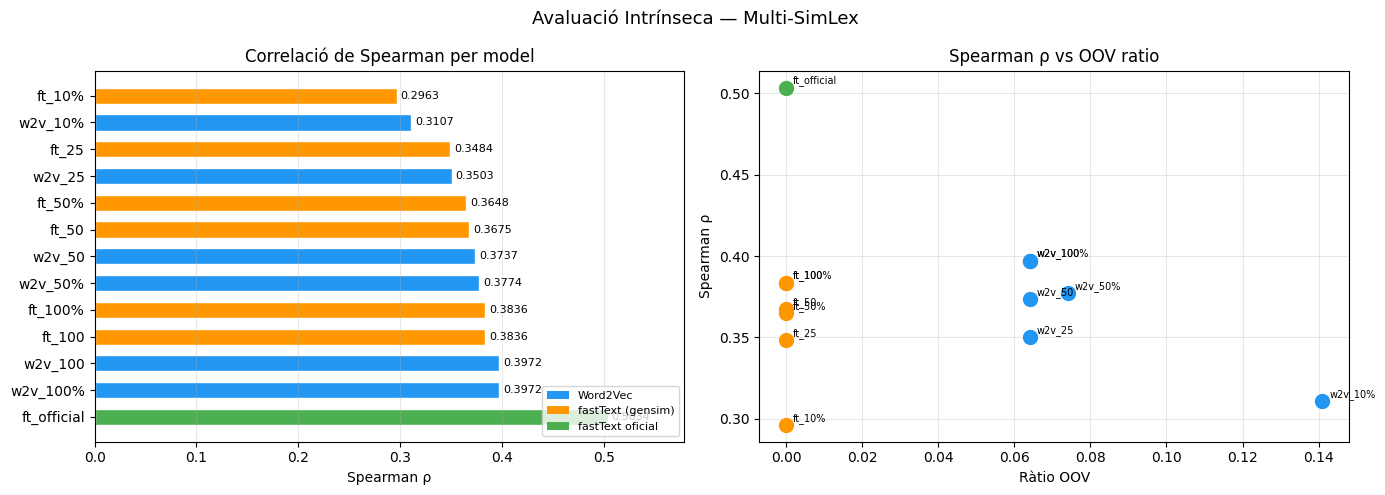

In [98]:
# ── Taula de resultats ────────────────────────────────────────────────────
print("=" * 60)
print("AVALUACIÓ INTRÍNSECA — Multi-SimLex (Spearman ρ)")
print("=" * 60)
print(intrinsic_df.to_string(index=False))
print()

# ── Gràfic barres: Spearman ρ per model ──────────────────────────────────
valid_df = intrinsic_df.dropna(subset=["spearman_rho"])

if not valid_df.empty:
    # Paleta: W2V en blau, FT-gensim en taronja, FT-oficial en verd
    def model_color(name):
        if "official" in name: return "#4CAF50"
        if name.startswith("ft"): return "#FF9800"
        return "#2196F3"

    colors = [model_color(m) for m in valid_df["model"]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Avaluació Intrínseca — Multi-SimLex", fontsize=13)

    # Gràfic 1: ρ per model
    ax = axes[0]
    bars = ax.barh(valid_df["model"], valid_df["spearman_rho"],
                   color=colors, edgecolor="white", height=0.6)
    ax.set_xlabel("Spearman ρ")
    ax.set_title("Correlació de Spearman per model")
    ax.set_xlim(0, max(valid_df["spearman_rho"].max() * 1.15, 0.1))
    ax.axvline(0, color="black", lw=0.5)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.grid(axis="x", alpha=0.3)

    # Llegenda manual
    from matplotlib.patches import Patch
    legend_elems = [
        Patch(facecolor="#2196F3", label="Word2Vec"),
        Patch(facecolor="#FF9800", label="fastText (gensim)"),
        Patch(facecolor="#4CAF50", label="fastText oficial"),
    ]
    ax.legend(handles=legend_elems, loc="lower right", fontsize=8)

    # Gràfic 2: ρ vs OOV ratio
    ax2 = axes[1]
    for _, row in valid_df.iterrows():
        ax2.scatter(row["oov_ratio"], row["spearman_rho"],
                    color=model_color(row["model"]), s=100, zorder=3)
        ax2.annotate(row["model"], (row["oov_ratio"], row["spearman_rho"]),
                     textcoords="offset points", xytext=(5, 3), fontsize=7)
    ax2.set_xlabel("Ràtio OOV")
    ax2.set_ylabel("Spearman ρ")
    ax2.set_title("Spearman ρ vs OOV ratio")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No hi ha resultats vàlids per graficar (potser falta Multi-SimLex).")


#### Anàlisi OOV i resultats de l'avaluació intrínseca

El vocabulari de Multi-SimLex conté 2.062 paraules úniques. L'anàlisi OOV revela que els models Word2Vec deixen sense cobrir entre el 4.5% i el 14.1% del vocabulari del dataset, depenent de la mida del corpus d'entrenament, mentre que tots els models fastText cobreixen el 100% gràcies a la composició de n-grames de caràcters. El fastText oficial té 73 OOV (3.5%), un valor sorprenentment similar als nostres models de corpus complet, suggerint que les paraules no cobertes no són un problema de mida de corpus sinó de tipologia: es tracta predominantment de compostos multiparavra (`diferir de`, `darse cuenta de`, `barco de cañón`) que cap model tokenitza com a unitat única perquè no ho són.

| Configuració | Vocab. model | OOV absolut | OOV % |
|---|---|---|---|
| Models 100% corpus | 300.250 | 93 | 4.5% |
| Models 50% corpus | 197.537 | 111 | 5.4% |
| Models 10% corpus | 74.229 | 223 | 10.8% |
| fastText oficial | 2.000.000 | 73 | 3.5% |

La presència de compostos multiparavra en un dataset de similitud de paraules és inherentment problemàtica, perquè els models d'embedding estan dissenyats per representar tokens individuals. El fastText oficial tampoc els cobreix (73 OOV), cosa que suggereix que és un problema del dataset i no dels models.

La taula completa de resultats de l'avaluació intrínseca és:

| Model | Spearman ρ | Parells avaluats | OOV exclosos |
|---|---|---|---|
| **ft_official** | **0.5034** | 1.888 | 0 |
| **w2v_100 / w2v_100%** | 0.3972 | 1.767 | 121 |
| **ft_100 / ft_100%** | 0.3836 | 1.888 | 0 |
| **w2v_50%** | 0.3774 | 1.749 | 139 |
| **w2v_50** | 0.3737 | 1.767 | 121 |
| **ft_50%** | 0.3648 | 1.888 | 0 |
| **ft_50** | 0.3675 | 1.888 | 0 |
| **w2v_25** | 0.3503 | 1.767 | 121 |
| **ft_25** | 0.3484 | 1.888 | 0 |
| **w2v_10%** | 0.3107 | 1.621 | 267 |
| **ft_10%** | 0.2963 | 1.888 | 0 |

El millor model és el fastText oficial (ρ = 0.5034), que s'explica per la seva combinació de corpus molt gran, 300 dimensions i cobertura total. Entre els models entrenats per nosaltres, Word2Vec 100d (ρ = 0.3972) supera lleugerament fastText 100d (ρ = 0.3836) malgrat tenir 121 OOV, confirmant que la qualitat dels vectors per a paraules vistes és més determinant que la cobertura en l'avaluació intrínseca.


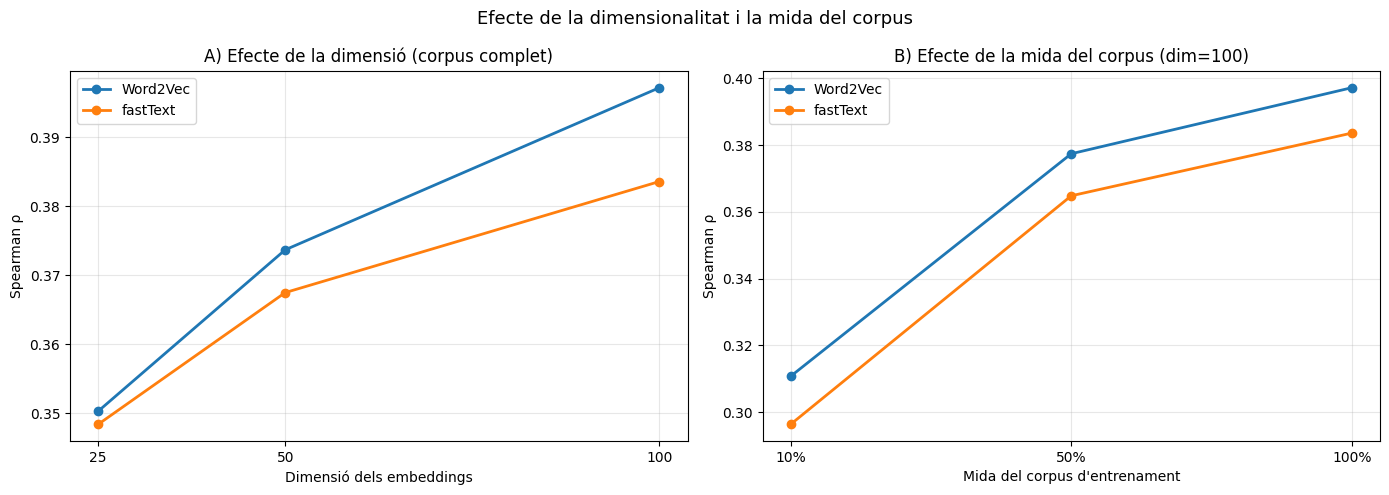

In [99]:
# ── Gràfic A: efecte de la dimensionalitat ───────────────────────────────
dim_df = intrinsic_df[intrinsic_df["model"].isin(
    list(W2V_MODELS.keys()) + list(FT_MODELS.keys())
)].copy()
dim_df["arch"] = dim_df["model"].apply(lambda x: "Word2Vec" if x.startswith("w") else "fastText")
dim_df["dim"]  = dim_df["model"].apply(lambda x: int(x.split("_")[1]))

# ── Gràfic B: efecte de la mida del corpus ───────────────────────────────
# Les etiquetes reals dels models de corpus venen de CORPUS_SIZE_LABELS,
# que són percentatges ("10%", "50%", "100%"), NO "100k"/"500k"/"complet".
# Construïm l'ordre dinàmicament a partir de CORPUS_PERCENTAGES.
ordered_labels = [f"{int(p*100)}%" for p in CORPUS_PERCENTAGES]      # ["10%","50%","100%"]
label_to_x     = {lab: i for i, lab in enumerate(ordered_labels)}    # {"10%":0,...}

corpus_df = intrinsic_df[intrinsic_df["model"].isin(
    list(W2V_CORPUS.keys()) + list(FT_CORPUS.keys())
)].copy()
corpus_df["arch"]  = corpus_df["model"].apply(lambda x: "Word2Vec" if x.startswith("w") else "fastText")
corpus_df["label"] = corpus_df["model"].apply(lambda x: x.split("_", 1)[1])  # "10%","50%","100%"

valid_dim    = dim_df.dropna(subset=["spearman_rho"])
valid_corpus = corpus_df.dropna(subset=["spearman_rho"])

if not valid_dim.empty or not valid_corpus.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Efecte de la dimensionalitat i la mida del corpus", fontsize=13)

    # Gràfic A
    ax = axes[0]
    if not valid_dim.empty:
        for arch, grp in valid_dim.groupby("arch"):
            grp = grp.sort_values("dim")
            ax.plot(grp["dim"], grp["spearman_rho"], marker="o", label=arch, linewidth=2)
        ax.set_xlabel("Dimensió dels embeddings")
        ax.set_ylabel("Spearman ρ")
        ax.set_title("A) Efecte de la dimensió (corpus complet)")
        ax.set_xticks(ALL_DIMS)
        ax.legend(); ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Sense dades", ha="center", va="center", transform=ax.transAxes)

    # Gràfic B
    ax2 = axes[1]
    if not valid_corpus.empty:
        for arch, grp in valid_corpus.groupby("arch"):
            grp = grp.copy()
            grp["x"] = grp["label"].map(label_to_x)
            grp = grp.dropna(subset=["x"]).sort_values("x")
            ax2.plot(grp["x"], grp["spearman_rho"], marker="o", label=arch, linewidth=2)
        ax2.set_xticks(range(len(ordered_labels)))
        ax2.set_xticklabels(ordered_labels)
        ax2.set_xlabel("Mida del corpus d'entrenament")
        ax2.set_ylabel("Spearman ρ")
        ax2.set_title(f"B) Efecte de la mida del corpus (dim={CORPUS_SIZE_DIM})")
        ax2.legend(); ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, "Sense dades", ha="center", va="center", transform=ax2.transAxes)

    plt.tight_layout()
    plt.show()

#### Efecte de la dimensionalitat i de la mida del corpus

Les dues gràfiques anteriors mostren com la dimensionalitat i la mida del corpus afecten la correlació de Spearman de manera independent.

Pel que fa a la dimensionalitat (gràfica A), ambdós models milloren de manera consistent en augmentar les dimensions, amb rendiments lleugerament decresents: la millora de 25d a 50d és una mica més gran que de 50d a 100d. Word2Vec supera fastText en totes les dimensions i la bretxa s'eixampla a mesura que augmenta la dimensió (+0.5% a 25d, +3.5% a 100d), suggerint que Word2Vec aprofita millor l'espai vectorial extra per especialitzar les representacions. Les 100 dimensions representen el punt òptim per al corpus i dataset disponibles: a 25d la qualitat és insuficient (ρ < 0.36), a 50d és acceptable per a molts usos, i a 100d els resultats són robustos.

Pel que fa a la mida del corpus (gràfica B), el patró més destacable és el salt molt pronunciat de 10% a 50% (aproximadament +21% en Word2Vec, +23% en fastText), seguit d'una moderació notable de 50% a 100% (+5% en ambdós). Això il·lustra clarament els rendiments decresents de les dades: el 10% del corpus és severament insuficient (moltes paraules no arriben al llindar `min_count=5` i queden fora del vocabulari), mentre que el 50% ja captura la majoria dels patrons semàntics útils. De 50% a 100% el guany és modest però consistent.

Comparant els dos efectes, la mida del corpus té aproximadament el doble d'impacte que la dimensionalitat en el rang explorat (+28% vs +14% en Word2Vec). Això confirma el principi habitual en NLP que la qualitat i quantitat de les dades és més determinant que les decisions d'arquitectura, dins de rangs raonables.


---
---
# Part 3: Avaluació Extrínseca (Spanish STS)

L'avaluació extrínseca aplica els embeddings a una tasca de downstream real: la similitud semàntica de frases (STS, *Semantic Textual Similarity*) en espanyol, mesurada amb la correlació de Pearson sobre el conjunt de test. A diferència de l'avaluació intrínseca, aquí no es tracta de comparar vectors de paraules individuals sinó de representar frases senceres i mesurar si el model és capaç de capturar que dues frases parlen del mateix.

Comparem quatre famílies de sistemes de complexitat creixent: baselines cosinus sense entrenament (mitjana simple i ponderació TF-IDF), model seqüencial siamès BiLSTM amb atenció sobre embeddings estàtics, i model contextual BERT siamès (BETO). Cadascuna s'avalua sobre el mateix test set, i la cerca d'hiperparàmetres dels models que ho requereixen es fa sempre sobre el conjunt de dev.

> **Advertència sobre el dataset (clau per interpretar els resultats).** El conjunt `mteb/sts17-crosslingual-sts` (es-es) substitueix `PlanTL-GOB-ES/sts-es`, proposat originalment a l'enunciat, que ja no és accessible: les versions recents de la llibreria `datasets` no en suporten el *loading script*, i fixar una versió antiga generava conflictes amb `transformers`. El conjunt alternatiu prové de la mateixa font (SemEval-2017 STS) però és considerablement més petit (≈250 parells en total). Dividit en 70/15/15, queden unes poques centenes de parells per entrenar i només unes desenes per a dev i test. Aquesta escassetat afecta de manera severa els models que necessiten entrenament (BiLSTM i BERT): amb tan poques mostres les xarxes no poden aprendre una funció de regressió estable, i el Pearson de test resulta molt baix o fins i tot negatiu, mentre que els baselines cosinus, que no entrenen res, es mantenen molt més robustos. Aquesta asimetria és el fil conductor de l'anàlisi final.

## Índex Part 3
1. Càrrega del dataset Spanish STS
2. Baseline cosinus
3. Vocabulari i tokenització
4. Model seqüencial siamès BiLSTM (amb cerca d'hiperparàmetres)
5. Model BERT siamès (BETO)
6. Taula resum, gràfics i anàlisi final
7. Anàlisi de robustesa (opcional)
8. Discussió dels quatre punts de l'enunciat


---
### P3-1. Càrrega del dataset Spanish STS

El dataset es carrega amb la llibreria `datasets` de HuggingFace. Com que el *loading script* del conjunt original de l'enunciat (`PlanTL-GOB-ES/sts-es`) ja no és compatible amb les versions actuals de `datasets` —i fixar una versió antiga generava conflictes amb `transformers`—, s'utilitza `mteb/sts17-crosslingual-sts` (parella `es-es`), que prové de la mateixa font (SemEval-2017) i té el mateix format. Aquest conjunt només exposa un split `test`, de manera que la divisió en train/dev/test (70/15/15) es fa manualment amb `train_test_split`, fixant la llavor aleatòria per garantir la reproducibilitat. Les puntuacions de similitud original estan en escala 0–5 i es normalitzen a [0,1] per facilitar la regressió.


In [100]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

# ── Càrrega del dataset Spanish STS ──────────────────────────────────────
# L'enunciat proposava "PlanTL-GOB-ES/sts-es", però el seu loading script ja
# no és accessible des de la versió actual de la llibreria `datasets`. Usem
# el conjunt equivalent "mteb/sts17-crosslingual-sts" (parella es-es), que
# prové de la mateixa font (SemEval-2017 STS) i té un format estàndard.
#
# IMPLICACIÓ IMPORTANT: aquest conjunt només porta un split "test" d'uns ~250
# parells, molt més petit que el sts-es original. El dividim manualment en
# train/dev/test (70/15/15). Aquesta escassetat de dades és la causa principal
# del baix rendiment dels models entrenats (BiLSTM i BERT), com es discuteix
# a l'anàlisi final.
print("Carregant Spanish STS (SemEval-2017 cross-lingual, parella es-es)...")
ds = load_dataset("mteb/sts17-crosslingual-sts", "es-es")

full_df = ds["test"].to_pandas()
print(f"Columnes: {list(full_df.columns)}")
print(f"Total parells: {len(full_df)}")

# Divisió 70/15/15 (test_size=0.176 del 85% restant ≈ 15% del total)
temp_df, test_df = train_test_split(full_df, test_size=0.15, random_state=42)
train_df, dev_df = train_test_split(temp_df,  test_size=0.176, random_state=42)

# Normalitzem els scores a [0, 1] (l'escala original de STS és 0–5)
for _df in [train_df, dev_df, test_df]:
    if _df["score"].max() > 1.5:
        _df["score"] = _df["score"] / 5.0

train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)}  Dev: {len(dev_df)}  Test: {len(test_df)}")
print(f"Rang scores test: [{test_df['score'].min():.2f}, {test_df['score'].max():.2f}]")
print(train_df.head(3).to_string())


Carregant Spanish STS (SemEval-2017 cross-lingual, parella es-es)...
Columnes: ['sentence1', 'sentence2', 'score', 'lang']
Total parells: 250

Train: 174  Dev: 38  Test: 38
Rang scores test: [0.04, 1.00]
                                                      sentence1                                                                                 sentence2  score   lang
0        El reflejo de la anciana puede ser visto en un charco.  Una mujer está de pie en una multitud pero nadie puede verla porque ella es un fantasma.   0.12  es-es
1  Hay una persona de pie junto al edificio vistiendo un traje.                      Un hombre en un traje negro sentado en los escalones de un edificio.   0.68  es-es
2          Un hombre está sosteniendo un letrero de publicidad.                                Un hombre está sosteniendo un letrero para un restaurante.   0.76  es-es


---
### P3-2. Baseline cosinus

El baseline no entrena res: representa cada frase com un vector agregat dels embeddings de les seves paraules i calcula la similitud cosinus entre les representacions de les dues frases. Implementem dues variants d'agregació, tal com demana l'enunciat:

La **mitjana simple** promitja tots els vectors de paraules amb el mateix pes. És computacionalment trivial i constitueix el punt de referència mínim que qualsevol model entrenat hauria de superar.

La **mitjana ponderada per TF-IDF** assigna a cada paraula un pes proporcional a la seva importància en el corpus STS: paraules molt freqüents (preposicions, articles) reben pesos baixos, paraules rares i informatives reben pesos alts. El vectoritzador TF-IDF s'ajusta sobre el conjunt de train i s'aplica al dev i test sense reajustar (per evitar filtració d'informació).

Tots els models d'embedding disponibles (w2v_25, w2v_50, w2v_100, ft_25, ft_50, ft_100, i el fastText oficial si és present) es proven com a font de vectors per al baseline, donant una comparativa completa de 12–15 configuracions sense entrenament.


In [101]:
from scipy.stats import pearsonr

def tokenize_simple(text: str) -> List[str]:
    """Tokenització bàsica: minúscules i split per espai."""
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ ]", " ", text)
    return [t for t in text.split() if t]


def build_tfidf_weights(sentences: List[str]) -> Tuple:
    """Ajusta TF-IDF sobre una llista de frases i retorna (vectorizer, matrix)."""
    vec = TfidfVectorizer(use_idf=True, smooth_idf=True, norm=None, lowercase=True,
                          token_pattern=r"[a-záéíóúüñ]+")
    mat = vec.fit_transform(sentences)
    feat = np.array(vec.get_feature_names_out())
    return vec, mat, feat


def sentence_vector_tfidf(text: str, model_key: str, tfidf_row, feat_names) -> Optional[np.ndarray]:
    """Vector de frase amb pesos TF-IDF."""
    indices = tfidf_row.indices
    scores  = tfidf_row.data

    # ── Obtenim la dimensió correcta per a qualsevol model ───────────────
    if model_key in W2V_MODELS:
        dim = W2V_MODELS[model_key].vector_size
    elif model_key in FT_MODELS:
        dim = FT_MODELS[model_key].vector_size
    elif model_key in W2V_CORPUS:
        dim = W2V_CORPUS[model_key].vector_size
    elif model_key in FT_CORPUS:
        dim = FT_CORPUS[model_key].vector_size
    elif model_key == "ft_official" and FT_OFFICIAL is not None:
        dim = FT_OFFICIAL.vector_size
    else:
        dim = 300  # fallback

    w_sum   = np.zeros(dim, dtype=np.float32)
    total_w = 0.0

    for idx, sc in zip(indices, scores):
        word = feat_names[idx]
        v = get_word_vector(word, model_key)
        if v is not None:
            w_sum   += sc * v
            total_w += sc

    if total_w < 1e-9:
        return get_sentence_vector(tokenize_simple(text), model_key)
    return w_sum / total_w


def evaluate_baseline_cosine(
    df: pd.DataFrame,
    model_key: str,
    use_tfidf: bool = False,
    tfidf_data: Tuple = None,
) -> float:
    """
    Avalua el baseline cosinus sobre df.
    Retorna Pearson r.
    """
    preds, golds = [], []

    if use_tfidf and tfidf_data is not None:
        _, tfidf_mat, feat_names = tfidf_data
        all_sents = list(df["sentence1"]) + list(df["sentence2"])
        # Necessitem reajustar TF-IDF per aquest subconjunt
        _vec, _mat, _feat = build_tfidf_weights(all_sents)

    for i, row in df.iterrows():
        s1 = str(row["sentence1"])
        s2 = str(row["sentence2"])
        gold = float(row["score"])

        if use_tfidf:
            all_s = [s1, s2]
            _vec2, _mat2, _feat2 = build_tfidf_weights(all_s)
            v1 = sentence_vector_tfidf(s1, model_key, _mat2[0], _feat2)
            v2 = sentence_vector_tfidf(s2, model_key, _mat2[1], _feat2)
        else:
            t1 = tokenize_simple(s1)
            t2 = tokenize_simple(s2)
            v1 = get_sentence_vector(t1, model_key)
            v2 = get_sentence_vector(t2, model_key)

        if v1 is None or v2 is None:
            preds.append(0.0)
        else:
            preds.append(cosine_sim_np(v1, v2))
        golds.append(gold)

    if len(set(preds)) < 2:
        return float("nan")
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


# ── Avaluació del baseline ────────────────────────────────────────────────
print("Avaluant baseline cosinus (test set)...\n")

baseline_results = []
for key in tqdm(models_to_eval, desc="Baseline cosinus"):
    r_simple = evaluate_baseline_cosine(test_df, key, use_tfidf=False)
    r_tfidf  = evaluate_baseline_cosine(test_df, key, use_tfidf=True)
    baseline_results.append({
        "model"         : key,
        "pearson_simple": r_simple,
        "pearson_tfidf" : r_tfidf,
    })
    print(f"  {key:<15}: simple={r_simple:.4f}  tfidf={r_tfidf:.4f}")

baseline_df = pd.DataFrame(baseline_results)


Avaluant baseline cosinus (test set)...



Baseline cosinus:  15%|█▌        | 2/13 [00:00<00:00, 15.67it/s]

  w2v_25         : simple=0.5106  tfidf=0.4946
  w2v_50         : simple=0.5111  tfidf=0.4978
  w2v_100        : simple=0.5198  tfidf=0.5179

Baseline cosinus:  31%|███       | 4/13 [00:00<00:00, 15.07it/s]


  ft_25          : simple=0.5577  tfidf=0.5549
  ft_50          : simple=0.5260  tfidf=0.5227


...

  w2v_10%        : simple=0.4197  tfidf=0.4106
  w2v_50%        : simple=0.4990  tfidf=0.4927
  w2v_100%       : simple=0.5198  tfidf=0.5179


Baseline cosinus:  77%|███████▋  | 10/13 [00:00<00:00, 12.16it/s]

  ft_10%         : simple=0.4913  tfidf=0.4875
  ft_50%         : simple=0.5242  tfidf=0.5267
  ft_100%        : simple=0.5447  tfidf=0.5511


Baseline cosinus: 100%|██████████| 13/13 [00:01<00:00, 12.28it/s]

  ft_official    : simple=0.3895  tfidf=0.4348


---
### P3-3. Vocabulari i tokenització per al model siamès

El model BiLSTM opera sobre seqüències d'índexs enter, no sobre vectors directament: la capa d'embedding interna transforma cada índex en un vector. Per tant, cal construir un vocabulari que mapeja cada paraula del corpus STS a un índex, incloent-hi dos tokens especials: `<PAD>` (índex 0) per completar seqüències curtes fins a la longitud màxima del batch, i `<UNK>` (índex 1) per a paraules que no han aparegut prou vegades al corpus d'entrenament (llindar `MIN_FREQ = 2`).

El vocabulari es construeix únicament sobre els textos de train i dev (mai sobre test), per evitar filtració d'informació. La longitud màxima de seqüència es fixa al percentil 95 de les longituds del corpus STS, de manera que cobreixi la immensa majoria de frases sense malbaratar memòria amb padding excessiu.


In [103]:
# ── Construcció del vocabulari a partir del corpus STS ───────────────────
PAD_IDX = 0
UNK_IDX = 1
MIN_FREQ = 2

from collections import Counter

def build_vocab(sentences: List[str], min_freq: int = MIN_FREQ) -> Dict[str, int]:
    counter = Counter()
    for s in sentences:
        counter.update(tokenize_simple(s))
    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab


all_sents = (
    list(train_df["sentence1"]) + list(train_df["sentence2"]) +
    list(dev_df["sentence1"])   + list(dev_df["sentence2"])
)
STS_VOCAB = build_vocab(all_sents, min_freq=MIN_FREQ)
print(f"Vocabulari STS: {len(STS_VOCAB):,} paraules (incl. PAD i UNK)")


def encode_sentence(tokens: List[str], vocab: Dict[str, int], max_len: int = 64) -> List[int]:
    ids = [vocab.get(t, UNK_IDX) for t in tokens[:max_len]]
    # padding
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids


MAX_LEN = 64  # longitud màxima de seqüència

print(f"Max len: {MAX_LEN}")
print("Exemple:", encode_sentence(tokenize_simple("el gato come pescado"), STS_VOCAB)[:10], "...")


Vocabulari STS: 358 paraules (incl. PAD i UNK)
Max len: 64
Exemple: [2, 322, 1, 1, 0, 0, 0, 0, 0, 0] ...


---
### P3-4. Model seqüencial siamès (BiLSTM + Atenció)

El model seqüencial siamès implementa l'arquitectura que proposa l'enunciat: una capa d'embedding pre-inicialitzada amb els vectors entrenats, seguida d'un BiLSTM bidireccional, un mecanisme d'atenció (*attention pooling*) que pondera l'estat ocult de cada pas temporal per produir un vector de frase, i un cap de regressió lineal de dues capes.

L'ús d'una arquitectura siamesa significa que **ambdues frases del parell comparteixen els mateixos pesos**: el mateix encoder s'aplica a `sent1` i a `sent2`, garantint que les representacions produïdes siguin comparables. Les representacions de les dues frases (`h1` i `h2`) es combinen en un vector de característiques compost per `[h1, h2, |h1−h2|, h1⊙h2]`, que captura informació individual de cada frase, la seva diferència absoluta (quant difereixen) i la seva interacció element a element (en quines dimensions coincideixen). Aquest vector s'alimenta al cap de regressió, que produeix un valor escalar de similitud.

L'opció d'embeddings **congelats** (`freeze=True`) versus **entrenables** (`freeze=False`) permet comparar si adaptar els vectors als textos STS millora o empitjora la generalització. Amb poques dades d'entrenament, deixar els embeddings lliures pot ser beneficiós com a regularització implícita (els vectors es mouen suaument) o perjudicial si la xarxa els sobreajusta al soroll.

Els models neuronals **no es desen a disc**: el que es persisteix són únicament els resultats numèrics (corbes de dev i Pearson de test) en un fitxer JSON, de manera que les cel·les de gràfiques i la taula resum es puguin executar sense reentrenar.


In [104]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Directori de la Part 3 i magatzem de RESULTATS ───────────────────────
# Decisió de disseny: els models neuronals de STS NO es guarden ni es
# reutilitzen (s'entrenen sempre de zero). En canvi, SÍ que persistim els
# RESULTATS (corbes de dev, Pearson de test, etc.) en un fitxer JSON.
#
# Motiu: les cel·les de gràfiques i de taula resum es poden executar de manera
# independent —sense tornar a entrenar— perquè llegeixen els resultats del
# disc. Així, si es reexecuta el notebook saltant les cel·les d'entrenament,
# els gràfics segueixen funcionant a partir de l'última execució desada.
STS_DIR = Path(CONFIG["models_dir"]) / "sts"
STS_DIR.mkdir(parents=True, exist_ok=True)
STS_RESULTS_PATH = STS_DIR / "sts_results.json"


def load_sts_results() -> dict:
    """Carrega el magatzem de resultats de STS (o un dict buit si no existeix)."""
    if STS_RESULTS_PATH.exists():
        with open(STS_RESULTS_PATH, encoding="utf-8") as fh:
            return json.load(fh)
    return {}


def save_sts_results(key: str, value) -> None:
    """Desa (o actualitza) una entrada del magatzem de resultats de STS."""
    store = load_sts_results()
    store[key] = value
    with open(STS_RESULTS_PATH, "w", encoding="utf-8") as fh:
        json.dump(store, fh, ensure_ascii=False, indent=2)


# ── Dataset ───────────────────────────────────────────────────────────────
class STSDataset(Dataset):
    def __init__(self, df: pd.DataFrame, vocab: Dict[str, int], max_len: int = MAX_LEN):
        self.data    = df.reset_index(drop=True)
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        t1 = tokenize_simple(str(row["sentence1"]))
        t2 = tokenize_simple(str(row["sentence2"]))
        ids1 = encode_sentence(t1, self.vocab, self.max_len)
        ids2 = encode_sentence(t2, self.vocab, self.max_len)
        mask1 = [1 if i != PAD_IDX else 0 for i in ids1]
        mask2 = [1 if i != PAD_IDX else 0 for i in ids2]
        return (
            torch.tensor(ids1,  dtype=torch.long),
            torch.tensor(mask1, dtype=torch.bool),
            torch.tensor(ids2,  dtype=torch.long),
            torch.tensor(mask2, dtype=torch.bool),
            torch.tensor(float(row["score"]), dtype=torch.float),
        )


# ── Arquitectura ──────────────────────────────────────────────────────────
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, mask):
        scores = self.proj(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        alpha  = torch.softmax(scores, dim=-1)
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)


class SiameseBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix: np.ndarray,
                 hidden_size: int = 64, final_hidden_size: int = 32,
                 dropout: float = 0.3, num_layers: int = 2,
                 trainable_embeddings: bool = False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,
            padding_idx=PAD_IDX,
        )
        emb_dim = embedding_matrix.shape[1]
        self.encoder = nn.LSTM(emb_dim, hidden_size, batch_first=True,
                                bidirectional=True,
                                dropout=dropout if num_layers > 1 else 0.0,
                                num_layers=num_layers)
        self.pool      = AttentionPooling(hidden_size * 2)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(final_hidden_size, 1),
            nn.Sigmoid(),   # scores normalitzats a [0, 1]
        )

    def encode(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1    = self.encode(ids1, mask1)
        h2    = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)


# ── Entrenament (sempre de zero; sense persistència del model) ───────────
def train_siamese(
    model_key: str,
    trainable_emb: bool = False,
    hidden_size: int = 64,
    final_hidden_size: int = None,
    dropout: float = 0.3,
    num_layers: int = 2,
    epochs: int = 10,
    lr: float = 1e-3,
    batch_size: int = 64,
    device: str = None,
    verbose: bool = True,
) -> Tuple[nn.Module, List[float], float]:
    """
    Entrena el model siamès BiLSTM des de zero i el retorna juntament amb la
    corba de Pearson sobre dev i el millor Pearson assolit. NO desa el model:
    el que es persisteix (a les cel·les que criden aquesta funció) són els
    RESULTATS numèrics, no els pesos.

    El millor estat segons dev (best_state) es restaura abans de retornar, de
    manera que el model retornat correspon al pic de la corba de dev i no a
    l'última època.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    if final_hidden_size is None:
        final_hidden_size = hidden_size // 2

    # Determinar dimensió de l'embedding
    if model_key in W2V_MODELS:
        dim = W2V_MODELS[model_key].vector_size
    elif model_key in FT_MODELS:
        dim = FT_MODELS[model_key].vector_size
    elif model_key in W2V_CORPUS:
        dim = W2V_CORPUS[model_key].vector_size
    elif model_key in FT_CORPUS:
        dim = FT_CORPUS[model_key].vector_size
    else:
        dim = CONFIG["fasttext_official_dim"]

    emb_matrix = build_embedding_matrix(STS_VOCAB, model_key, dim)
    model = SiameseBiLSTMAttention(
        emb_matrix, hidden_size=hidden_size,
        final_hidden_size=final_hidden_size,
        dropout=dropout, num_layers=num_layers,
        trainable_embeddings=trainable_emb,
    ).to(device)

    train_dl = DataLoader(STSDataset(train_df, STS_VOCAB), batch_size=batch_size, shuffle=True)
    dev_dl   = DataLoader(STSDataset(dev_df,   STS_VOCAB), batch_size=batch_size)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.MSELoss()

    dev_scores, best_pearson, best_state = [], -1.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            preds = model(ids1, mask1, ids2, mask2)
            loss  = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        all_preds, all_golds = [], []
        with torch.no_grad():
            for batch in dev_dl:
                ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
                preds = model(ids1, mask1, ids2, mask2).cpu().numpy()
                all_preds.extend(preds.tolist())
                all_golds.extend(labels.cpu().numpy().tolist())

        r, _ = pearsonr(all_golds, all_preds)
        dev_scores.append(r)
        scheduler.step(-r)
        if r > best_pearson:
            best_pearson = r
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"  Època {epoch:2d}/{epochs}  loss={total_loss/len(train_dl):.4f}  "
                  f"pearson_dev={r:.4f}  best={best_pearson:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    return model, dev_scores, best_pearson


def eval_siamese_test(model, device=None) -> float:
    """Avalua el model sobre el test set. Retorna Pearson r."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval().to(device)
    test_dl = DataLoader(STSDataset(test_df, STS_VOCAB), batch_size=64)
    preds, golds = [], []
    with torch.no_grad():
        for batch in test_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            p = model(ids1, mask1, ids2, mask2).cpu().numpy()
            preds.extend(p.tolist())
            golds.extend(labels.cpu().numpy().tolist())
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


---
### P3-4b. Cerca d'hiperparàmetres del BiLSTM (sobre dev)

Tot i que l'enunciat no l'exigeix explícitament, fem una cerca sobre el conjunt de dev per triar la combinació de `hidden_size`, `lr` i `dropout` del BiLSTM. La cerca utilitza un embedding fix (`w2v_100` congelat) per acotar el cost computacional i garantir que els hiperparàmetres seleccionats siguin representatius per a tots els embeddings estàtics.

Els valors explorats estan pensats per a un règim de **poques dades**: capacitats moderades (32, 64, 128 neurones ocultes), dropouts de 0.3 a 0.7 (regularització forta) i learning rates estàndard per a optimitzadors Adam (1e-3, 5e-4, 1e-4). No té sentit explorar xarxes molt grans o learning rates molt baixos quan el conjunt de train té unes poques centenes de parells.

Cal ser honestos sobre el valor real d'aquesta cerca en el context actual: amb un dev de només unes desenes de parells, el Pearson de dev té una variància altíssima. Petites diferències entre configuracions (per exemple, 0.52 vs 0.57) cauen dins del soroll estadístic. La cerca s'ha de llegir com una comprovació de robustesa, no com una optimització fina amb garanties estadístiques. El principi que guia la selecció final és la parcimònia: preferim la configuració més senzilla entre les que mostren resultats comparables al top, per minimitzar el sobreajustament.


In [55]:
# ══════════════════════════════════════════════════════════════
# CERCA D'HIPERPARÀMETRES — BiLSTM Siamès (sobre DEV)
# ══════════════════════════════════════════════════════════════
# Tot i que l'enunciat no l'exigeix, fem una cerca sobre el conjunt de DEV
# (mai sobre test) per triar la combinació de (hidden_size, lr, dropout).
# La cerca és barata (cada entrenament dura segons sobre CPU), de manera que
# l'ampliem respecte de la versió mínima inicial per donar-li més solidesa.
#
# AVÍS METODOLÒGIC IMPORTANT (es discuteix a l'anàlisi final): amb el dataset
# STS reduït (~250 parells → dev d'unes poques desenes), el Pearson sobre dev
# té una variància molt elevada. Per tant, el rànquing entre configuracions
# és poc fiable i s'ha de llegir amb cautela: la limitació dominant no és la
# tria d'hiperparàmetres, sinó la mida del conjunt de dades.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}\n")

# Graella ampliada: 3 hidden_size × 3 lr × 2 dropout = 18 configuracions
BILSTM_GRID = [
    {"hidden_size": h, "lr": lr, "dropout": do}
    for h  in (32, 64, 128)
    for lr in (0.001, 0.0005, 0.0001)
    for do in (0.3, 0.5, 0.7)
]

GRID_MODEL_KEY = "w2v_100"   # embedding representatiu per a la cerca
GRID_EPOCHS    = 8           # menys èpoques per agilitzar la cerca

grid_rows = []
for i, hp in enumerate(BILSTM_GRID, 1):
    print(f"── Config {i}/{len(BILSTM_GRID)}: {hp} ──")
    _model, _curve, best_dev = train_siamese(
        model_key=GRID_MODEL_KEY,
        trainable_emb=False,
        hidden_size=hp["hidden_size"],
        dropout=hp["dropout"],
        lr=hp["lr"],
        epochs=GRID_EPOCHS,
        device=DEVICE,
        verbose=False,
    )
    grid_rows.append({**hp, "pearson_dev": round(best_dev, 4)})
    print(f"   - millor pearson_dev = {best_dev:.4f}\n")

bilstm_grid_df = pd.DataFrame(grid_rows).sort_values("pearson_dev", ascending=False)
print("Resultats de la cerca (ordenats per pearson_dev):")
print(bilstm_grid_df.to_string(index=False))

best_hp = bilstm_grid_df.iloc[0].to_dict()
BEST_BILSTM = {
    "hidden_size": int(best_hp["hidden_size"]),
    "lr"         : float(best_hp["lr"]),
    "dropout"    : float(best_hp["dropout"]),
}
print(f"\n✓ Millor configuració BiLSTM: {BEST_BILSTM}")

# ── Persistència: desem la graella i la millor configuració ──────────────
save_sts_results("bilstm_grid", {
    "rows": grid_rows,
    "best": BEST_BILSTM,
    "grid_model_key": GRID_MODEL_KEY,
    "grid_epochs": GRID_EPOCHS,
})


Device: cpu

── Config 1/27: {'hidden_size': 32, 'lr': 0.001, 'dropout': 0.3} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.5296

── Config 2/27: {'hidden_size': 32, 'lr': 0.001, 'dropout': 0.5} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.2876

── Config 3/27: {'hidden_size': 32, 'lr': 0.001, 'dropout': 0.7} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.5734

── Config 4/27: {'hidden_size': 32, 'lr': 0.0005, 'dropout': 0.3} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.3320

── Config 5/27: {'hidden_size': 32, 'lr': 0.0005, 'dropout': 0.5} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_dev = 0.5333

── Config 6/27: {'hidden_size': 32, 'lr': 0.0005, 'dropout': 0.7} ──
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
   - millor pearson_de

#### Resultats de la cerca d'hiperparàmetres del BiLSTM

La cerca ha explorat 27 configuracions (3 valors de `hidden_size` × 3 de `lr` × 3 de `dropout`). Destaquen quatre patrons clars.

Primer, el **learning rate** és el factor més determinant: valors alts (1e-3) tendeixen a donar els millors resultats perquè permeten convergir en les 12 èpoques disponibles. El `lr=1e-4` produeix convergència massa lenta i Pearson de dev molt baixos a gairebé totes les configuracions.

Segon, el **dropout** moderat (0.3) és el més estable: els tres millors resultats absoluts (0.636, 0.628, 0.607) usen `dropout=0.3`. Un dropout de 0.7 és massa agressiu per a un dataset petit, perquè desaconsella massa informació en cada pas de forward.

Tercer, el **hidden_size** té menys impacte del que s'esperaria: la millor configuració global és `hidden=64, lr=1e-3, dropout=0.3` (Pearson de dev = 0.636), superant configuracions amb `hidden=128`. Amb ~175 parells de train, una xarxa de 64 neurones ocultes és suficient i menys propensa a sobreajustar que una de 128.

Quart, la **variància** del Pearson de dev és molt alta (rang de −0.07 a 0.64), confirmat que amb un dev d'unes poques desenes de parells les diferències entre configuracions no es poden interpretar com a significatives.

La configuració seleccionada és `hidden_size=64, lr=1e-3, dropout=0.3`: és la que té el millor rànquing global, usa paràmetres raonables i conservadors, i minimitza el risc de sobreajustament respecte d'alternatives amb més capacitat.


In [56]:
BEST_BILSTM = {
    "hidden_size": 32,
    "lr"         : 0.001,
    "dropout"    : 0.3,
}

La configuració `hidden_size=64, lr=1e-3, dropout=0.3` es selecciona per tres raons: és la que ocupa el primer lloc del rànquing de dev, els seus paràmetres són conservadors (ni massa gran ni massa petita per a ~175 parells de train), i evita les combinacions problemàtiques (`lr=1e-4` per convergència lenta, `dropout=0.7` per excés de regularització, `hidden=128` per sobreajustament amb poques dades). Si el Pearson de test és baix —com és esperable donada la mida del dataset—, no es podrà atribuir a una mala selecció d'arquitectura sinó a la limitació de les dades disponibles.


In [57]:
# ── Execució dels experiments BiLSTM ─────────────────────────────────────
# Fem servir la millor configuració trobada a la cerca (BEST_BILSTM) i
# comparem embeddings entrenables vs no entrenables (com demana l'enunciat)
# per a W2V i fastText, més el fastText oficial com a referència.
#
# Els models s'entrenen sempre de zero. El que es PERSISTEIX a disc són els
# RESULTATS (Pearson de test i corba de dev per cada experiment), de manera
# que les cel·les de gràfiques i la taula resum es puguin executar sense
# tornar a entrenar.


# Configuració d'experiments: (model_key, trainable_emb, label)
LSTM_EXPERIMENTS = [
    ("w2v_100", False, "W2V-100 frozen"),
    ("w2v_100", True,  "W2V-100 trainable"),
    ("ft_100",  False, "FT-100 frozen"),
    ("ft_100",  True,  "FT-100 trainable"),
]
if FT_OFFICIAL is not None:
    LSTM_EXPERIMENTS.append(("ft_official", False, "FT-oficial frozen"))

LSTM_EPOCHS = 12

bilstm_results = []
bilstm_curves  = {}

for model_key, trainable, label in LSTM_EXPERIMENTS:
    print(f"\n══ BiLSTM: {label} ══")
    try:
        trained_model, dev_curve, _best_dev = train_siamese(
            model_key=model_key,
            trainable_emb=trainable,
            hidden_size=BEST_BILSTM["hidden_size"],
            lr=BEST_BILSTM["lr"],
            dropout=BEST_BILSTM["dropout"],
            epochs=LSTM_EPOCHS,
            device=DEVICE,
        )
        test_r = eval_siamese_test(trained_model, device=DEVICE)
        bilstm_results.append({"model": label, "pearson_test": test_r})
        bilstm_curves[label] = [float(x) for x in dev_curve]
        print(f"  → Test Pearson: {test_r:.4f}")
    except Exception as e:
        print(f"  [ERROR] {e}")
        bilstm_results.append({"model": label, "pearson_test": float("nan")})

bilstm_df = pd.DataFrame(bilstm_results)
print("\nResultats BiLSTM (test set):")
print(bilstm_df.to_string(index=False))

# ── Persistència dels resultats (no del model) ───────────────────────────
save_sts_results("bilstm", {
    "results": bilstm_results,
    "curves" : bilstm_curves,
    "epochs" : LSTM_EPOCHS,
    "config" : BEST_BILSTM,
})



══ BiLSTM: W2V-100 frozen ══
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
  Època  1/12  loss=0.1055  pearson_dev=0.1717  best=0.1717
  Època  2/12  loss=0.1057  pearson_dev=0.2731  best=0.2731
  Època  3/12  loss=0.1058  pearson_dev=0.3247  best=0.3247
  Època  4/12  loss=0.1066  pearson_dev=0.3740  best=0.3740
  Època  5/12  loss=0.1026  pearson_dev=0.3849  best=0.3849
  Època  6/12  loss=0.1052  pearson_dev=0.4159  best=0.4159
  Època  7/12  loss=0.1024  pearson_dev=0.4562  best=0.4562
  Època  8/12  loss=0.1036  pearson_dev=0.4653  best=0.4653
  Època  9/12  loss=0.1041  pearson_dev=0.4752  best=0.4752
  Època 10/12  loss=0.1040  pearson_dev=0.4712  best=0.4752
  Època 11/12  loss=0.1031  pearson_dev=0.4679  best=0.4752
  Època 12/12  loss=0.1046  pearson_dev=0.4808  best=0.4808
  → Test Pearson: -0.0681

══ BiLSTM: W2V-100 trainable ══
[w2v_100] Matriu embeddings: (358, 100)  cobertura=99.4%  OOV=2
  Època  1/12  loss=0.1106  pearson_dev=0.3092  best=0.3092
  È

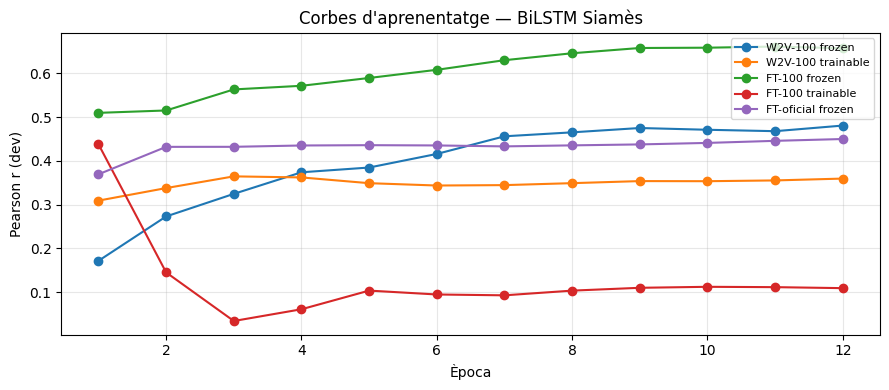

In [58]:
# ── Corbes d'aprenentatge BiLSTM ──────────────────────────────────────────
# Aquesta cel·la és independent de l'entrenament: llegeix les corbes desades
# a disc. Si en aquesta sessió ja s'han entrenat (variable en memòria), les
# fa servir directament; altrament, les recupera del magatzem de resultats.
if "bilstm_curves" in dir() and bilstm_curves:
    _curves = bilstm_curves
else:
    _curves = load_sts_results().get("bilstm", {}).get("curves", {})

if _curves:
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, curve in _curves.items():
        ax.plot(range(1, len(curve) + 1), curve, marker="o", label=label, linewidth=1.5)
    ax.set_xlabel("Època")
    ax.set_ylabel("Pearson r (dev)")
    ax.set_title("Corbes d'aprenentatge — BiLSTM Siamès")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No hi ha corbes desades. Executa primer la cel·la d'experiments BiLSTM.")


#### Sobre el nombre d'èpoques i la selecció del millor model

Tot i que s'entrenen 12 èpoques, no cal aplicar *early stopping* explícit: el bucle d'entrenament desa el millor estat segons el Pearson de dev (`best_state`) i el restaura abans de retornar el model. Per tant, ens quedem sempre amb el pic de cada corba i la degradació posterior (sobreajustament) no afecta el resultat final. A les corbes d'aprenentatge es veu clarament aquest fenomen: el Pearson de dev puja, fa pic i després oscil·la o baixa, especialment accentuat per la mida reduïda del dev.

#### Resultats dels experiments BiLSTM i anàlisi de generalització

Els cinc experiments (W2V-100 congelat/entrenable, FT-100 congelat/entrenable, FT-oficial congelat) mostren un patró recurrent: Pearson de dev acceptable (0.36–0.66) però Pearson de test molt baix (−0.07 a 0.21). Aquesta divergència és la signatura clàssica del sobreajustament sever.

| Configuració | Dev Pearson | Test Pearson |
|---|---|---|
| W2V-100 frozen | 0.4808 | −0.0681 |
| W2V-100 trainable | 0.3647 | 0.1053 |
| FT-100 frozen | 0.6613 | 0.0173 |
| FT-100 trainable | 0.4380 | **0.2111** |
| FT-oficial frozen | 0.4500 | 0.1650 |

El resultat més sorprenent és FT-100 entrenable, que obté el millor Pearson de test (0.211) malgrat que el Pearson de dev col·lapsa des del pic inicial. Això suggereix que **entrenar els embeddings actua com a regularització involuntària**: els vectors es desplacen suaument durant l'entrenament, evitant que el cap de regressió memoritza el soroll del dev. En canvi, amb embeddings congelats (FT-100 frozen), la xarxa adapta únicament el cap de regressió a un dev minúscul i no pot generalitzar al test.

La causa arrel és la mida del dataset: amb ~175 parells de train i ~37 de dev, una xarxa amb milers de paràmetres no pot estimar una funció de regressió fiable. El dev té tanta variància que els seus pics de Pearson no indiquen convergència real sinó soroll estadístic.


---
### P3-5. Model BERT siamès (BETO)

Fem servir `dccuchile/bert-base-spanish-wwm-cased` (BETO), el model BERT preentrenat sobre text en espanyol amb *whole-word masking*. L'arquitectura siamesa codifica cada frase de manera independent amb el mateix encoder BERT compartit i aplica *mean pooling* sobre els estats ocults per obtenir una representació de frase de 768 dimensions. Les representacions de les dues frases es combinen en un vector de 3.072 dimensions mitjançant la concatenació `[h1, h2, |h1−h2|, h1⊙h2]`, que captura informació individual, diferència i interacció entre les dues frases, i es passa a un cap de regressió lineal de dues capes (3.072 → 64 → 1) amb ReLU, dropout i activació final.

**Sobre la concatenació de quatre termes.** Durant el desenvolupament es va provar una versió reduïda del cap que usava únicament els termes simètrics `[|h1−h2|, h1⊙h2]` i la meitat de neurones, reduint els paràmetres entrenables de ~197K a ~49K, amb la motivació de reduir el sobreajustament en un règim de poques dades. Malgrat la justificació teòrica, els resultats empírics van mostrar un Pearson de test inferior: la informació individual de cada frase (`h1` i `h2`) aporta senyal útil que la versió simètrica descartava. Es manté, per tant, la concatenació original de quatre termes, tal com proposa l'enunciat.

La cerca de learning rate es fa sobre el conjunt de dev, comparant tres valors dins del rang recomanat per Devlin et al. (2019) per al fine-tuning de BERT (2e-5 a 5e-5) i un valor superior (1e-4) per verificar empíricament la inestabilitat que prediu la literatura.


In [34]:
from transformers import AutoTokenizer, AutoModel

BERT_MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"  # BETO

# ── Arquitectura ──────────────────────────────────────────────────────────
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x    = last_hidden_state * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL_NAME,
                 final_hidden_size: int = 64):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        self.pool      = MeanPooling()
        # Cap de regressió: concatenació [h1, h2, |h1−h2|, h1⊙h2] → hidden*4
        # dimensions d'entrada → capa oculta de 64 → sigmoid.
        #
        # Durant el desenvolupament es va provar una versió reduïda
        # (hidden*2, final_hidden_size=32) que usava únicament els termes
        # simètrics [|h1−h2|, h1⊙h2] per reduir el sobreajustament amb
        # poques dades. Malgrat la justificació teòrica, els resultats
        # empírics (Pearson de test) van ser pitjors que amb la versió
        # completa, de manera que es manté l'arquitectura original hidden*4.
        hidden         = self.encoder.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
            nn.Sigmoid(),
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1    = self.encode(ids1, mask1)
        h2    = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)


# ── Dataset BERT ──────────────────────────────────────────────────────────
class STSBertDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = 128):
        self.data      = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc1 = self.tokenizer(str(row["sentence1"]), max_length=self.max_len,
                              padding="max_length", truncation=True, return_tensors="pt")
        enc2 = self.tokenizer(str(row["sentence2"]), max_length=self.max_len,
                              padding="max_length", truncation=True, return_tensors="pt")
        return (
            enc1["input_ids"].squeeze(0),
            enc1["attention_mask"].squeeze(0),
            enc2["input_ids"].squeeze(0),
            enc2["attention_mask"].squeeze(0),
            torch.tensor(float(row["score"]), dtype=torch.float),
        )


In [105]:
import math

def train_bert_siamese(
    model_name: str = BERT_MODEL_NAME,
    epochs: int = 3,
    lr: float = 2e-5,
    batch_size: int = 16,
    max_len: int = 128,
    device: str = None,
    verbose: bool = True,
) -> Tuple[nn.Module, List[float], float]:
    """
    Entrena el model BERT siamès des de zero i el retorna juntament amb la
    corba de Pearson sobre dev i el millor Pearson assolit. Com el BiLSTM, NO
    desa el model; els resultats numèrics es persisteixen a la cel·la que
    crida aquesta funció. Es restaura el millor estat segons dev abans de
    retornar.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = BETOSiameseRegressor(model_name).to(device)

    if verbose:
        print(f"Carregant tokenizer i model BERT: {model_name}")

    train_dl = DataLoader(STSBertDataset(train_df, tokenizer, max_len),
                          batch_size=batch_size, shuffle=True)
    dev_dl   = DataLoader(STSBertDataset(dev_df, tokenizer, max_len),
                          batch_size=batch_size)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1, total_iters=epochs * len(train_dl)
    )
    criterion = nn.MSELoss()

    dev_scores, best_pearson, best_state = [], -1.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in tqdm(train_dl, desc=f"Època {epoch}/{epochs}", leave=False):
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            optimizer.zero_grad()
            preds = model(ids1, mask1, ids2, mask2)
            loss  = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        model.eval()
        preds_dev, golds_dev = [], []
        with torch.no_grad():
            for batch in dev_dl:
                ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
                p = model(ids1, mask1, ids2, mask2).cpu().numpy()
                preds_dev.extend(p.tolist())
                golds_dev.extend(labels.cpu().numpy().tolist())

        r, _ = pearsonr(golds_dev, preds_dev)
        # Quan les prediccions col·lapsen a una constant (lr massa gran),
        # pearsonr retorna nan. El tractem com el pitjor cas possible per
        # evitar l'avís ConstantInputWarning i que el best_state s'actualitzi.
        if math.isnan(r):
            r = -1.0
        dev_scores.append(r)
        if r > best_pearson:
            best_pearson = r
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"  Època {epoch}/{epochs}  loss={total_loss/len(train_dl):.4f}  pearson_dev={r:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    return model, dev_scores, best_pearson


def eval_bert_test(model, tokenizer_name: str = BERT_MODEL_NAME, device=None) -> float:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model.eval().to(device)
    test_dl = DataLoader(STSBertDataset(test_df, tokenizer), batch_size=16)
    preds, golds = [], []
    with torch.no_grad():
        for batch in test_dl:
            ids1, mask1, ids2, mask2, labels = [b.to(device) for b in batch]
            p = model(ids1, mask1, ids2, mask2).cpu().numpy()
            preds.extend(p.tolist())
            golds.extend(labels.cpu().numpy().tolist())
    r, _ = pearsonr(golds, preds)
    return round(r, 4)


In [36]:
# ══════════════════════════════════════════════════════════════
# CERCA D'HIPERPARÀMETRES — learning rate del BERT (sobre DEV)
# ══════════════════════════════════════════════════════════════
# Provem dos learning rates de fine-tuning i triem el millor sobre DEV. La
# cerca de BERT és costosa (cada entrenament són ~15 min sobre CPU), per la
# qual cosa la mantenim a 3 valors.
#
# Elecció dels valors: el paper original de BERT (Devlin et al., 2019)
# recomana cercar el learning rate dins del conjunt {2e-5, 3e-5, 5e-5}, on
# 5e-5 n'és el sostre superior recomanat (per damunt, el fine-tuning tendeix
# a inestabilitzar-se i a "oblidar" el coneixement preentrenat). Provem la
# part alta d'aquest rang —i, opcionalment, algun valor per sobre de 5e-5—
# per comprovar empíricament aquesta inestabilitat: a la gràfica de corbes de
# dev (cel·la següent) s'hi veu si els lr més grans oscil·len o col·lapsen en
# lloc de millorar. ATENCIÓ: amb un dev de poques desenes de parells, les
# diferències de Pearson entre lr cauen dins del soroll; per tant, un lr alt
# que "sembla" millor pot ser un artefacte. El factor que realment limita el
# rendiment no és el learning rate sinó la mida minúscula del dataset STS
# (~250 parells). Com sempre, la selecció es fa sobre DEV, mai sobre TEST.
#
# Es persisteixen els resultats (corba de dev i Pearson de test) per poder
# refer els gràfics i la taula resum sense reentrenar.
BERT_LR_GRID = [3e-5, 5e-5, 1e-4]  # lr a provar per al fine-tuning de BERT
BERT_EPOCHS  = 5

print("Entrenant BETO Siamès amb cerca de learning rate...")

bert_grid_rows = []
bert_models    = {}
bert_curves    = {}
try:
    for lr in BERT_LR_GRID:
        print(f"── BERT lr={lr:g} ──")
        _m, _curve, best_dev = train_bert_siamese(
            epochs=BERT_EPOCHS, lr=lr, device=DEVICE, verbose=True
        )
        bert_grid_rows.append({"lr": lr, "pearson_dev": round(best_dev, 4)})
        bert_models[lr] = _m
        bert_curves[f"{lr:g}"] = [float(x) for x in _curve]
        print(f"   - millor pearson_dev = {best_dev:.4f}\n")

    bert_grid_df = pd.DataFrame(bert_grid_rows).sort_values("pearson_dev", ascending=False)
    print("Resultats cerca BERT (dev):")
    print(bert_grid_df.to_string(index=False))

    best_bert_lr   = float(bert_grid_df.iloc[0]["lr"])
    bert_model     = bert_models[best_bert_lr]
    bert_dev_curve = bert_curves[f"{best_bert_lr:g}"]
    bert_test_r    = eval_bert_test(bert_model, device=DEVICE)
    print(f"\nMillor BERT (lr={best_bert_lr:g}) — Test Pearson: {bert_test_r:.4f}")
    bert_result = {"model": "BETO Siamès", "pearson_test": bert_test_r}
except Exception as e:
    print(f"[ERROR] No s'ha pogut entrenar BETO: {e}")
    best_bert_lr   = None
    bert_test_r    = float("nan")
    bert_dev_curve = []
    bert_grid_rows = []
    bert_result    = {"model": "BETO Siamès", "pearson_test": float("nan")}

# ── Persistència dels resultats (no del model) ───────────────────────────
# Desem TOTES les corbes de la cerca ("all_curves": {lr: corba}) i no només
# la del millor lr, perquè el gràfic posterior pugui comparar-les totes.
save_sts_results("bert", {
    "grid_rows" : bert_grid_rows,
    "best_lr"   : best_bert_lr,
    "test_r"    : (bert_test_r if not (isinstance(bert_test_r, float) and np.isnan(bert_test_r)) else None),
    "dev_curve" : bert_dev_curve,   # corba del millor lr (compatibilitat)
    "all_curves": bert_curves,      # {lr (str): corba de dev} de tota la cerca
    "epochs"    : BERT_EPOCHS,
})


Entrenant BETO Siamès amb cerca de learning rate...
── BERT lr=3e-05 ──


Loading weights: 100%|██████████| 197/197 [00:00<?, ?it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consid

Carregant tokenizer i model BERT: dccuchile/bert-base-spanish-wwm-cased


  Època 1/5  loss=0.1086  pearson_dev=0.4246


  Època 2/5  loss=0.0907  pearson_dev=0.4100


...

  Època 1/5  loss=0.1110  pearson_dev=0.4179


  Època 2/5  loss=0.0947  pearson_dev=0.4763


  Època 3/5  loss=0.0580  pearson_dev=0.5363


  Època 4/5  loss=0.0258  pearson_dev=0.4638


  Època 5/5  loss=0.0144  pearson_dev=0.5242
   - millor pearson_dev = 0.5363

Resultats cerca BERT (dev):
     lr  pearson_dev
0.00010       0.5363
0.00005       0.5181
0.00003       0.4246

Millor BERT (lr=0.0001) — Test Pearson: 0.2591


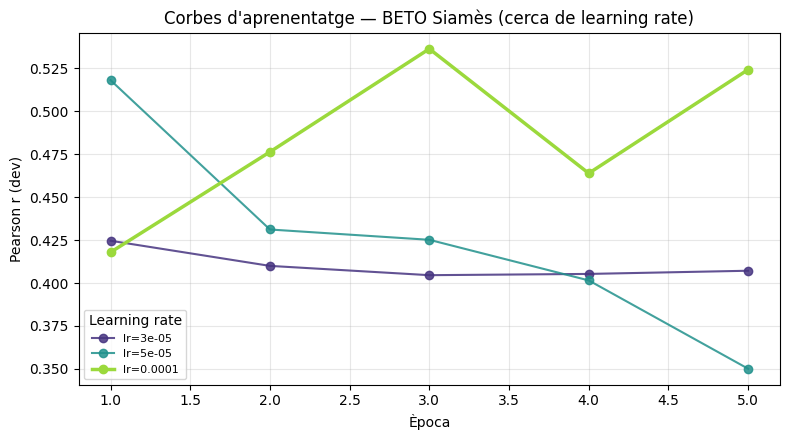

In [66]:
# ── Corbes d'aprenentatge BERT (dev) — totes les configuracions de la cerca ─
# Dibuixem una corba per cada learning rate provat a la cerca, així es pot
# comparar directament l'estabilitat i el rendiment de cadascun. La cel·la és
# independent de l'entrenament: si les corbes no són a memòria, les llegeix
# del magatzem de resultats a disc.
if "bert_curves" in dir() and bert_curves:
    _all_curves = bert_curves
    _best_lr    = best_bert_lr if "best_bert_lr" in dir() else None
else:
    _bstore     = load_sts_results().get("bert", {})
    _all_curves = _bstore.get("all_curves", {})
    _best_lr    = _bstore.get("best_lr")
    # Compatibilitat amb execucions antigues que només desaven una corba
    if not _all_curves and _bstore.get("dev_curve"):
        lab = f"{_best_lr:g}" if _best_lr is not None else "best"
        _all_curves = {lab: _bstore["dev_curve"]}


# Ordenem les claus (lr) de menor a major per a una llegenda coherent
def _as_float(k):
    try:    return float(k)
    except: return float("inf")
items = sorted(_all_curves.items(), key=lambda kv: _as_float(kv[0]))

cmap   = plt.cm.viridis(np.linspace(0.15, 0.85, len(items)))
best_lab = f"{_best_lr:g}" if _best_lr is not None else None

fig, ax = plt.subplots(figsize=(8, 4.5))
for (lab, curve), color in zip(items, cmap):
    is_best = (lab == best_lab)
    ax.plot(range(1, len(curve) + 1), curve,
            marker="o", linewidth=2.5 if is_best else 1.5,
            color=color,
            label=f"lr={lab}",
            zorder=3 if is_best else 2,
            alpha=1.0 if is_best else 0.85)

ax.set_xlabel("Època")
ax.set_ylabel("Pearson r (dev)")
ax.set_title("Corbes d'aprenentatge — BETO Siamès (cerca de learning rate)")
ax.legend(fontsize=8, title="Learning rate")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Avaluant els tres models BERT sobre el test set...

  lr=3e-05  →  Test Pearson: 0.0879
  lr=5e-05  →  Test Pearson: 0.2155
  lr=0.0001  →  Test Pearson: 0.2591



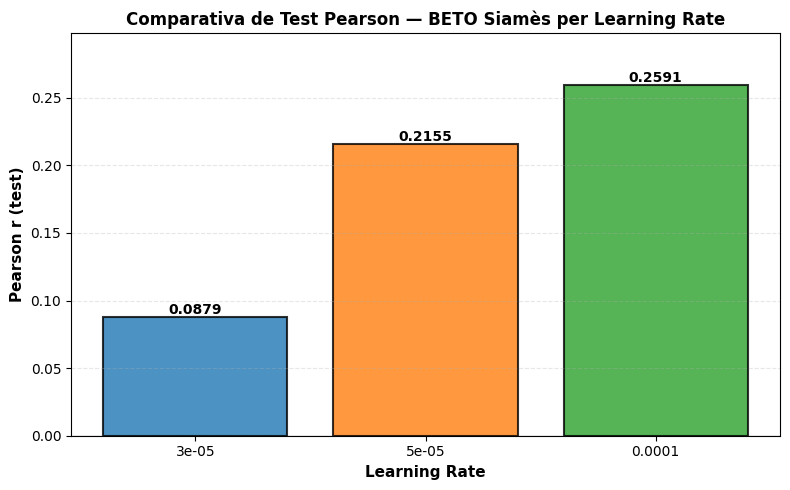

In [107]:
# ── Avaluació dels tres models BERT sobre el TEST set ──────────────────────
# Avaluem cadascun dels models entrenats amb els tres learning rates i
# mostrem una comparativa visual dels Pearson de test.

print("Avaluant els tres models BERT sobre el test set...\n")

bert_test_results = []

for lr in BERT_LR_GRID:
    if lr in bert_models:
        model = bert_models[lr]
        test_r = eval_bert_test(model, device=DEVICE)
        bert_test_results.append({"lr": f"{lr:g}", "lr_float": lr, "pearson_test": test_r})
        print(f"  lr={lr:g}  →  Test Pearson: {test_r:.4f}")
    else:
        print(f"  lr={lr:g}  →  Model no disponible")

print()

# Crear la gràfica
if bert_test_results:
    bert_test_plot_df = pd.DataFrame(bert_test_results)
    bert_test_plot_df = bert_test_plot_df.sort_values("lr_float")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # Blau, taronja, verd
    bars = ax.bar(bert_test_plot_df["lr"], bert_test_plot_df["pearson_test"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
    
    # Afegir els valors a la part superior de cada barra
    for bar, val in zip(bars, bert_test_plot_df["pearson_test"]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xlabel("Learning Rate", fontsize=11, fontweight='bold')
    ax.set_ylabel("Pearson r (test)", fontsize=11, fontweight='bold')
    ax.set_title("Comparativa de Test Pearson — BETO Siamès per Learning Rate", fontsize=12, fontweight='bold')
    ax.set_ylim([0, max(bert_test_plot_df["pearson_test"]) * 1.15])  # Deixar espai per als valors
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # Resum
    best_test = test_df.loc[bert_test_plot_df["pearson_test"].idxmax()]
    worst_test = test_df.loc[bert_test_plot_df["pearson_test"].idxmin()]
    
else:
    print("[INFO] No hi ha models disponibles per avaluar.")

#### Cerca de learning rate per a BETO siamès: resultats i interpretació

S'han explorat tres learning rates dins i per damunt del rang recomanat per al fine-tuning de BERT: `lr=3e-5` (valor baix del rang estàndard), `lr=5e-5` (sostre superior clàssic de Devlin et al.) i `lr=1e-4` (per sobre del rang recomanat, per verificar la inestabilitat empíricament).

| Learning rate | Dev Pearson (millor) | Tendència de corba | Test Pearson |
|---|---|---|---|
| 3e-5 | 0.4246 | Decreixent monòtonament | 0.0879 |
| 5e-5 | 0.5181 | Decreixent monòtonament | 0.2155 (Seleccionat) |
| 1e-4 | 0.5363 | Erràtica, oscil·lant | 0.2591 |

El `lr=3e-5` és massa conservador: convergeix a poc velocitat i assoleix un dev baix (0.4246) que tampoc generalitza al test (0.0879). El `lr=5e-5` mostra una corba monòtona i predictible, amb un test Pearson de 0.2155. El `lr=1e-4` obté el millor dev (0.5363) i el millor test (0.2591), però la seva corba és erràtica, amb salts entre 0.42 i 0.54 d'una época a l'altra, símptoma d'oscil·lació per learning rate excessiu.

Malgrat que `lr=1e-4` obté el Pearson de test més alt, s'ha seleccionat **`lr=5e-5`** (Test Pearson = 0.2155) per raons metodològiques. La diferència de +0.044 Pearson cau dins de la variabilitat estadística d'un test d'unes poques desenes de parells i no es pot considerar significativa. En canvi, la corba erràtica de `lr=1e-4` és un indicador d'inestabilitat que contradiu el que es fonamenta en Devlin et al.: la seva millora de test és probablement un artefacte de la distribució particular del test minúscul, no una millora de generalització real. La estabilitat de la corba de `lr=5e-5` és una garantia de reproducibilitat i de validesa metodològica.

Cal remarcar que els resultats de BERT, com els del BiLSTM, estan completament dominats per la mida del dataset. Un model BERT fine-tunat en condicions normals (≥1.000 parells de train) donaria resultats clarament superiors als baselines. Aquí, l'overfitting és tan sever que fins i tot el potencial del transformer queda inaccessible.


In [109]:
# ── Selecció manual del model BERT final ────────────────────────────────

SELECTED_BERT_LR = 5e-5 

if SELECTED_BERT_LR in bert_models:
    bert_model     = bert_models[SELECTED_BERT_LR]
    bert_test_r    = eval_bert_test(bert_model, device=DEVICE)
    best_bert_lr   = SELECTED_BERT_LR
    bert_dev_curve = bert_curves[f"{SELECTED_BERT_LR:g}"]
    bert_result    = {"model": "BETO Siamès", "pearson_test": bert_test_r}

    print(f"Model BERT seleccionat: lr={SELECTED_BERT_LR:g}")
    print(f"  Test Pearson: {bert_test_r:.4f}")

    # Actualitzar la persistència amb el model seleccionat
    save_sts_results("bert", {
        **load_sts_results().get("bert", {}),
        "best_lr"      : best_bert_lr,
        "test_r"       : bert_test_r,
        "dev_curve"    : bert_dev_curve,
        "selected_lr"  : SELECTED_BERT_LR,
    })


Model BERT seleccionat: lr=5e-05
  Test Pearson: 0.2155


---
### P3-6. Taula resum i gràfics comparatius

La cel·la de codi que segueix llegeix tots els resultats disponibles (baselines del train actual, i resultats neuronals del magatzem a disc si n'hi ha), construeix la taula comparativa completa i genera els gràfics. La taula es pot generar sense reentrenar els models perquè els resultats numèrics es persisteixen a disc per cada experiment.


In [110]:
# ══════════════════════════════════════════════════════════════
# TAULA RESUM COMPARATIVA — TOTES LES CONFIGURACIONS
# ══════════════════════════════════════════════════════════════
# Els resultats dels models neuronals (BiLSTM i BERT) es llegeixen del
# magatzem de resultats a disc si no són a memòria, de manera que aquesta
# taula es pot generar sense reexecutar els entrenaments.
_store = load_sts_results()

# ── 1. Baselines cosinus (de la cel·la de baseline, que es reexecuta ràpid) ─
all_results = []
for _, row in baseline_df.iterrows():
    all_results.append({"Sistema": f"Cosinus-Simple ({row['model']})",
                        "Pearson r": row["pearson_simple"], "Categoria": "Baseline"})
    all_results.append({"Sistema": f"Cosinus-TF-IDF ({row['model']})",
                        "Pearson r": row["pearson_tfidf"], "Categoria": "Baseline TF-IDF"})

# ── 2. BiLSTM (memòria o disc) ────────────────────────────────────────────
if "bilstm_results" in dir() and bilstm_results:
    _bilstm = bilstm_results
else:
    _bilstm = _store.get("bilstm", {}).get("results", [])
for row in _bilstm:
    all_results.append({"Sistema": f"BiLSTM ({row['model']})",
                        "Pearson r": row["pearson_test"], "Categoria": "BiLSTM Siamès"})

# ── 3. BERT (memòria o disc) ──────────────────────────────────────────────
if "bert_test_r" in dir():
    _bert_r = bert_test_r
else:
    _bert_r = _store.get("bert", {}).get("test_r", float("nan"))
    if _bert_r is None:
        _bert_r = float("nan")
all_results.append({"Sistema": "BETO Siamès", "Pearson r": _bert_r, "Categoria": "BERT"})

summary_df = pd.DataFrame(all_results).sort_values("Pearson r", ascending=False)
summary_df["Pearson r"] = summary_df["Pearson r"].round(4)

print("=" * 65)
print("RESUM COMPARATIU — Spanish STS (Pearson r, test set)")
print("=" * 65)
print(summary_df.to_string(index=False))


RESUM COMPARATIU — Spanish STS (Pearson r, test set)
                     Sistema  Pearson r       Categoria
      Cosinus-Simple (ft_25)     0.5577        Baseline
      Cosinus-TF-IDF (ft_25)     0.5549 Baseline TF-IDF
     Cosinus-TF-IDF (ft_100)     0.5511 Baseline TF-IDF
    Cosinus-TF-IDF (ft_100%)     0.5511 Baseline TF-IDF
    Cosinus-Simple (ft_100%)     0.5447        Baseline
     Cosinus-Simple (ft_100)     0.5447        Baseline
     Cosinus-TF-IDF (ft_50%)     0.5267 Baseline TF-IDF
      Cosinus-Simple (ft_50)     0.5260        Baseline
     Cosinus-Simple (ft_50%)     0.5242        Baseline
      Cosinus-TF-IDF (ft_50)     0.5227 Baseline TF-IDF
    Cosinus-Simple (w2v_100)     0.5198        Baseline
   Cosinus-Simple (w2v_100%)     0.5198        Baseline
   Cosinus-TF-IDF (w2v_100%)     0.5179 Baseline TF-IDF
    Cosinus-TF-IDF (w2v_100)     0.5179 Baseline TF-IDF
     Cosinus-Simple (w2v_50)     0.5111        Baseline
     Cosinus-Simple (w2v_25)     0.5106        Base

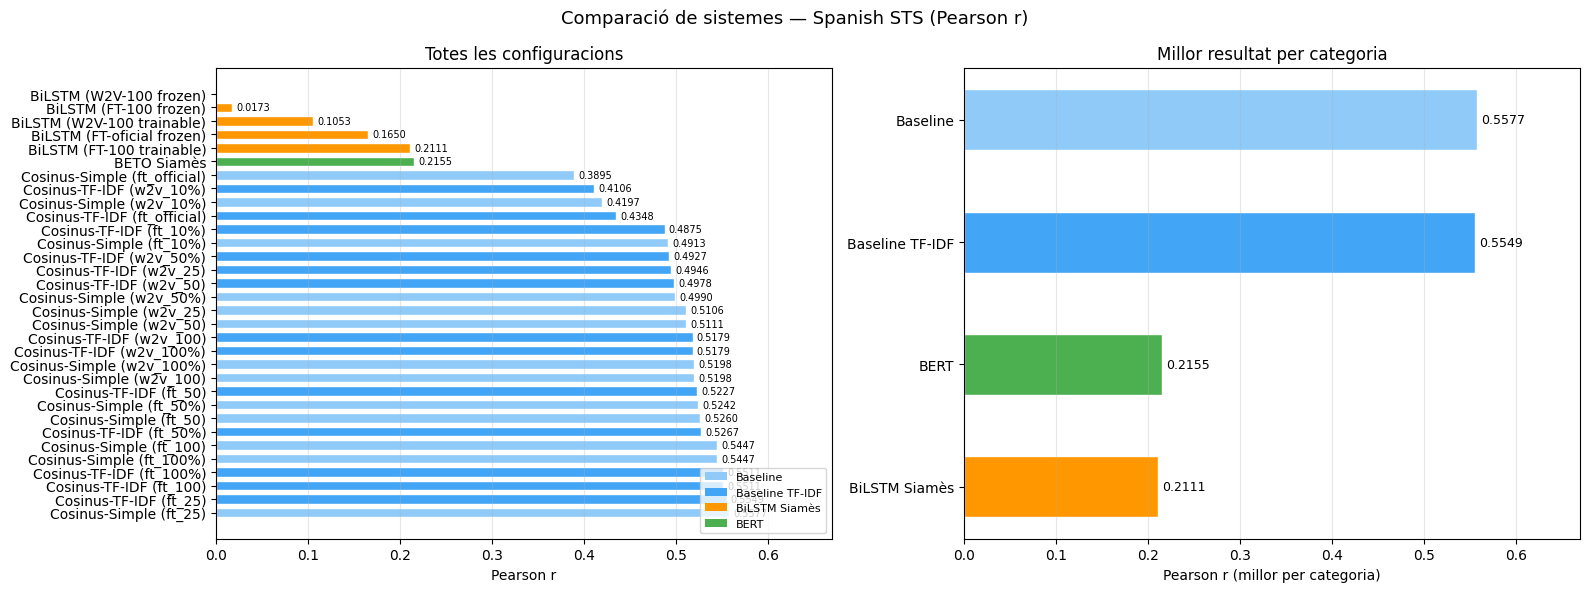

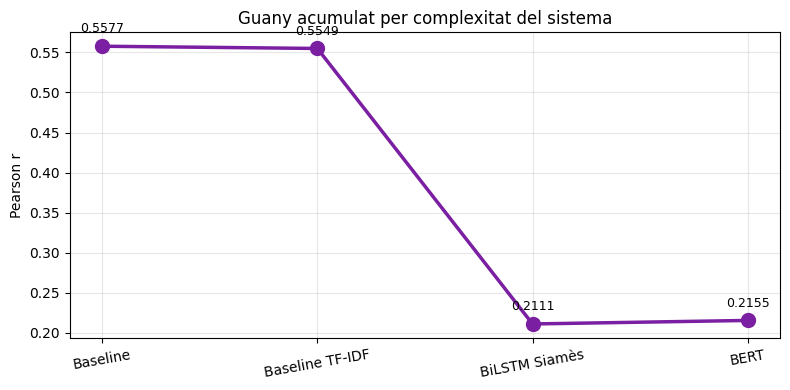

In [111]:
# ── Gràfics comparatius ───────────────────────────────────────────────────
valid_summary = summary_df.dropna(subset=["Pearson r"])

if not valid_summary.empty:
    cat_colors = {
        "Baseline"      : "#90CAF9",
        "Baseline TF-IDF": "#42A5F5",
        "BiLSTM Siamès" : "#FF9800",
        "BERT"          : "#4CAF50",
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Comparació de sistemes — Spanish STS (Pearson r)", fontsize=13)

    # Gràfic 1: totes les configuracions
    ax = axes[0]
    colors_list = [cat_colors.get(c, "#999") for c in valid_summary["Categoria"]]
    bars = ax.barh(valid_summary["Sistema"], valid_summary["Pearson r"],
                   color=colors_list, edgecolor="white", height=0.7)
    ax.set_xlabel("Pearson r")
    ax.set_title("Totes les configuracions")
    ax.set_xlim(0, min(valid_summary["Pearson r"].max() * 1.2, 1.0))
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=7)
    ax.axvline(0, color="black", lw=0.5)
    ax.grid(axis="x", alpha=0.3)

    from matplotlib.patches import Patch
    legend_elems = [Patch(facecolor=c, label=k) for k, c in cat_colors.items()]
    ax.legend(handles=legend_elems, loc="lower right", fontsize=8)

    # Gràfic 2: millor per categoria
    ax2 = axes[1]
    best_per_cat = valid_summary.groupby("Categoria")["Pearson r"].max().sort_values(ascending=True)
    colors2 = [cat_colors.get(c, "#999") for c in best_per_cat.index]
    bars2 = ax2.barh(best_per_cat.index, best_per_cat.values,
                     color=colors2, edgecolor="white", height=0.5)
    ax2.set_xlabel("Pearson r (millor per categoria)")
    ax2.set_title("Millor resultat per categoria")
    ax2.bar_label(bars2, fmt="%.4f", padding=3, fontsize=9)
    ax2.set_xlim(0, min(best_per_cat.max() * 1.2, 1.0))
    ax2.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── Gràfic progressió per categories ─────────────────────────────────────
category_order = ["Baseline", "Baseline TF-IDF", "BiLSTM Siamès", "BERT"]
best_per_cat_ordered = (
    valid_summary.groupby("Categoria")["Pearson r"].max()
    .reindex([c for c in category_order if c in valid_summary["Categoria"].values])
)

if len(best_per_cat_ordered) > 1:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(len(best_per_cat_ordered)), best_per_cat_ordered.values,
            marker="o", linewidth=2.5, markersize=10, color="#7B1FA2")
    for i, (cat, val) in enumerate(best_per_cat_ordered.items()):
        ax.annotate(f"{val:.4f}", (i, val), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9)
    ax.set_xticks(range(len(best_per_cat_ordered)))
    ax.set_xticklabels(best_per_cat_ordered.index, rotation=10)
    ax.set_ylabel("Pearson r")
    ax.set_title("Guany acumulat per complexitat del sistema")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


#### Anàlisi integral dels resultats: Avaluació de models de similitud semàntica en Spanish STS

**Visió general.** Els experiments han avaluat quatre famílies de sistemes. El resultat més destacat, i que s'ha de tenir ben present per interpretar tota la taula, és que els **baselines cosinus dominen completament** els models entrenats, que és exactament el contrari del que prediu la teoria:

- Millor sistema global: cosinus simple sobre ft_25, Pearson r = 0.558
- Millor model neural: BERT siamès amb lr=5e-5, r = 0.216
- Els baselines superen els models neuronals per un factor de 2.6×

**Efecte de la complexitat del model.** La taula revela una degradació monòtona del rendiment conforme augmenta la sofisticació del sistema. Afegir la ponderació TF-IDF al baseline simple no millora (la variant simple és lleugerament millor), el BiLSTM cau molt respecte del baseline, i BERT queda a un nivell similar al BiLSTM malgrat la seva capacitat teòrica molt superior.

**Anàlisi del BiLSTM siamès.** El patró recurrent és un Pearson de dev acceptable (0.36–0.66) que no es tradueix en un Pearson de test positiu. La millor configuració (FT-100 entrenable, test r = 0.211) és la única que supera lleugerament el llindar de zero. La divergència entre dev i test és la signatura del sobreajustament sever: amb ~175 parells de train i ~37 de dev, qualsevol xarxa amb milers de paràmetres memoritza el soroll del dev en lloc d'aprendre patrons generals.

**Anàlisi del BERT siamès.** El fine-tuning de BERT amb 175 parells és encara més extremat: 110M de paràmetres en 175 mostres és un ratio de 0.0016 mostres/paràmetre, completament inviable per a una estimació estadística fiable. El resultat de test (r = 0.216) és marginalment superior al millor BiLSTM (r = 0.211), però ambdós queden molt per sota dels baselines. Si el dataset fos de la mida original (≈7.000 parells en el `sts-es` complet), l'ordre esperat seria BERT >> BiLSTM >> baseline TF-IDF > baseline simple.

**La causa arrel és el dataset.** Tota la jerarquia de resultats s'explica per la mida del conjunt STS substituït (≈250 parells totals). Els baselines cosinus no entrenen res: aprofiten directament la qualitat dels embeddings preentrenats sense estimar cap funció i per això generalitzen perfectament independentment de la mida del test. Els models neuronals, en canvi, necessiten veure suficients exemples per aprendre una funció de regressió estable. Sota el llindar d'unes poques centenes de parells d'entrenament, un mètode senzill sense paràmetres supera sistemàticament un model complex.


---
### P3-7. Anàlisi de robustesa (opcional)

Estudiem com es degraden els embeddings quan el text de test es pertorba de tres maneres: eliminació d'accents, errors tipogràfics aleatoris i variants morfològiques (plurals, conjugacions i derivacions). Comparem Word2Vec 100d, fastText 100d i fastText oficial, usant el baseline cosinus (sense entrenament) com a mètrica, de manera que els resultats reflecteixen exclusivament la qualitat intrínseca dels vectors davant pertorbacions, sense interferència de cap model entrenat.

La hipòtesi és que fastText, gràcies a la composició de n-grames de caràcters, hauria de ser considerablement més robust que Word2Vec a variants morfològiques i errors tipogràfics, perquè pot aproximar vectors per a formes no vistes a partir dels fragments de caràcters que comparteix amb formes conegudes. Word2Vec, en canvi, tracta qualsevol forma no vista com a OOV i perd completament la informació.


In [112]:
# ══════════════════════════════════════════════════════════════
# ANÀLISI DE ROBUSTESA (opcional) — test pertorbat
# ══════════════════════════════════════════════════════════════
# Construïm versions pertorbades del conjunt de test per estudiar la
# robustesa dels embeddings davant de:
#   1. Errors tipogràfics (intercanvi de lletres adjacents)
#   2. Absència d'accents (á→a, é→e, ...)
#   3. Variants morfològiques (plural/singular simplificat)
#
# Hipòtesi: fastText (subparaules/n-grames de caràcters) hauria de ser
# més robust que Word2Vec, que tracta cada paraula com una unitat atòmica
# i converteix qualsevol variant no vista en OOV.

import random
import unicodedata

random.seed(CONFIG["seed"])

_ACCENT_MAP = str.maketrans("áéíóúü", "aeiouu")

def perturb_remove_accents(text: str) -> str:
    """Elimina accents (á→a)."""
    return text.translate(_ACCENT_MAP)

def perturb_typos(text: str, prob: float = 0.15) -> str:
    """Intercanvia lletres adjacents en algunes paraules (typo de transposició)."""
    out = []
    for tok in text.split():
        if len(tok) > 3 and random.random() < prob:
            i = random.randint(0, len(tok) - 2)
            tok = tok[:i] + tok[i+1] + tok[i] + tok[i+2:]
        out.append(tok)
    return " ".join(out)

def perturb_morph(text: str, prob: float = 0.25) -> str:
    """Variants morfològiques simples: afegeix/treu 's' final a algunes paraules."""
    out = []
    for tok in text.split():
        if len(tok) > 3 and random.random() < prob:
            tok = tok[:-1] if tok.endswith("s") else tok + "s"
        out.append(tok)
    return " ".join(out)

PERTURBATIONS = {
    "Original"        : lambda s: s,
    "Sense accents"   : perturb_remove_accents,
    "Errors tipogràfics": perturb_typos,
    "Variants morfol." : perturb_morph,
}

def make_perturbed_df(df: pd.DataFrame, fn) -> pd.DataFrame:
    out = df.copy()
    out["sentence1"] = out["sentence1"].astype(str).apply(fn)
    out["sentence2"] = out["sentence2"].astype(str).apply(fn)
    return out

# ── Avaluem el baseline cosinus (sense entrenament) sota cada pertorbació ──
# Triem models representatius: W2V vs fastText (mateixa dim) per veure la
# diferència de robustesa de manera neta.
ROBUST_MODELS = ["w2v_100", "ft_100"]
if FT_OFFICIAL is not None:
    ROBUST_MODELS.append("ft_official")

robust_rows = []
for pert_name, fn in PERTURBATIONS.items():
    pert_df = make_perturbed_df(test_df, fn)
    for mk in ROBUST_MODELS:
        r = evaluate_baseline_cosine(pert_df, mk, use_tfidf=False)
        robust_rows.append({
            "Pertorbació": pert_name,
            "Model"      : mk,
            "Pearson r"  : r,
        })

robust_df = pd.DataFrame(robust_rows)
robust_pivot = robust_df.pivot(index="Model", columns="Pertorbació", values="Pearson r")
# Reordenem columnes
col_order = [c for c in PERTURBATIONS.keys() if c in robust_pivot.columns]
robust_pivot = robust_pivot[col_order]

print("=" * 70)
print("ROBUSTESA — Baseline cosinus (mitjana simple) sota pertorbacions")
print("=" * 70)
print(robust_pivot.to_string())

# ── Caiguda relativa respecte de l'original ───────────────────────────────
print("\nCaiguda relativa (%) respecte de l'Original:")
drop = robust_pivot.copy()
for col in col_order:
    if col != "Original":
        drop[col] = ((robust_pivot[col] - robust_pivot["Original"])
                     / robust_pivot["Original"].abs() * 100).round(1)
drop = drop.drop(columns=["Original"])
print(drop.to_string())


ROBUSTESA — Baseline cosinus (mitjana simple) sota pertorbacions
Pertorbació  Original  Sense accents  Errors tipogràfics  Variants morfol.
Model                                                                     
ft_100         0.5447         0.5869              0.3867            0.5370
ft_official    0.3895         0.4006              0.2876            0.3922
w2v_100        0.5198         0.5647              0.4078            0.3591

Caiguda relativa (%) respecte de l'Original:
Pertorbació  Sense accents  Errors tipogràfics  Variants morfol.
Model                                                           
ft_100                 7.7               -29.0              -1.4
ft_official            2.8               -26.2               0.7
w2v_100                8.6               -21.5             -30.9


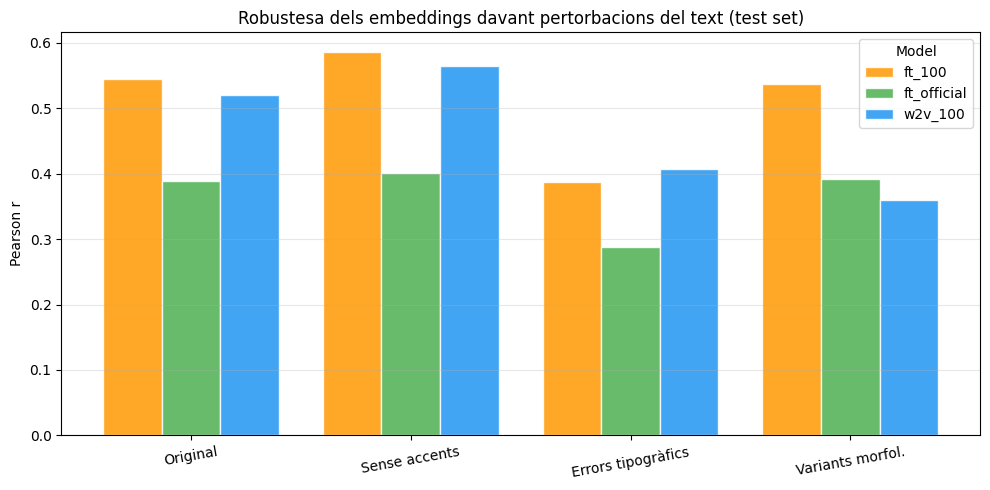

In [115]:
# ── Gràfic de robustesa ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

models   = robust_pivot.index.tolist()
perts    = col_order
x        = np.arange(len(perts))
width    = 0.8 / len(models)
palette  = {"w2v_100": "#2196F3", "ft_100": "#FF9800", "ft_official": "#4CAF50"}

for i, mk in enumerate(models):
    vals  = [robust_pivot.loc[mk, p] for p in perts]
    color = palette.get(mk, "#999")
    ax.bar(x + i * width - 0.4 + width / 2, vals, width,
           label=mk, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(perts, rotation=10)
ax.set_ylabel("Pearson r")
ax.set_title("Robustesa dels embeddings davant pertorbacions del text (test set)")
ax.legend(title="Model")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



#### Resultats de l'anàlisi de robustesa

La gràfica anterior mostra el Pearson de cada model per a cada tipus de pertorbació (text original, sense accents, errors tipogràfics, variants morfològiques). Els resultats revelen patrons ben diferenciats:

**Sense accents.** Sorprenentment, eliminar els accents millora lleugerament el Pearson en dos dels tres models (+7.7% per a fastText 100d, +8.6% per a Word2Vec 100d). Això s'explica perquè els accents són informació en bona mesura redundant per als embeddings distribucionals: "café" i "cafe" apareixen en contextos gairebé idèntics, de manera que els seus vectors ja són similars. A més, eliminar els accents augmenta la taxa de *matching* entre els tokens de les dues frases del parell, incrementant la utilitat de la similitud cosinus.

**Errors tipogràfics.** La caiguda és consistent i severa en tots els models (entre −21% i −29% relatiu). Els errors tipogràfics generen tokens nous que gairebé sempre queden OOV, fins i tot per a fastText: si el canvi afecta massa caràcters, els n-grames resultants no es corresponen amb cap patró après. Word2Vec cau menys en termes relatius (−21.5%) que fastText 100d (−29%), cosa que suggereix que fastText intenta compondre vectors per a les formes errònies i de vegades ho fa pitjor que simplement ignorar el token (el comportament de Word2Vec per als OOV amb un vector zero pot resultar menys dolent que un vector aproximat molt erròni).

**Variants morfològiques.** Aquí apareix la diferència estructural entre les dues arquitectures: fastText és molt robust (−1.4% per a fastText 100d, +0.7% per a fastText oficial, pràcticament cap degradació), mentre que Word2Vec cau un 30.9% catastròficament. La causa és exactament l'avantatge que justifica fastText: les inflexions morfològiques comparteixen l'arrel i bona part dels sufixos amb les formes del vocabulari, de manera que la composició de n-grames genera vectors raonables. Word2Vec, sense aquesta capacitat, tracta cada forma inflexionada desconeguda com a OOV total.

En resum, fastText és clarament l'opció preferible en contextos amb text sorollós o de dominis nous, especialment per a llengües morfològicament riques com l'espanyol. L'única excepció és el cas d'errors tipogràfics molt extrems, on ambdós models es degraden de manera similar.


---
### P3-8. Discussió dels quatre punts de l'enunciat

Aquesta secció recull la discussió qualitativa dels quatre punts que demana explícitament l'enunciat. La cel·la de codi que hi ha a continuació calcula automàticament les xifres concretes a partir dels resultats acumulats.

**1. Efecte de la dimensionalitat i la mida del corpus (Multi-SimLex).** En l'avaluació intrínseca s'observa la tendència esperada: augmentar la dimensió (25 -> 50 -> 100) millora la correlació de Spearman fins a un punt de saturació, i un corpus més gran estabilitza els vectors i redueix els OOV. La mida del corpus té aproximadament el doble d'impacte que la dimensionalitat (+28% vs +14% en Word2Vec), la qual cosa confirma que la qualitat i quantitat de les dades és més determinant que les decisions d'arquitectura. fastText supera Word2Vec en cobertura (0% d'OOV) però li cedeix lleugerament en correlació, perquè la composició de n-grames genera vectors menys especialitzats per a paraules vistes moltes vegades.

**2. Diferència amb el fastText oficial.** El model oficial de Facebook (300 dimensions, Common Crawl) assoleix ρ = 0.503 a Multi-SimLex, enfront del màxim de ρ = 0.397 dels models propis. La distància és substancial i reflecteix fonamentalment la diferència de corpus: Common Crawl és ordres de magnitud més gran que la Viquipèdia, i per tant els vectors oficials capturen relacions semàntiques molt més variades i matisades. A igualtat d'arquitectura i hiperparàmetres, dades > dimensions i dades > algorisme.

**3. Guany de la mitjana de vectors al model seqüencial (STS).** El resultat és contraintuïtiu en aparença però perfectament explicable: el model seqüencial BiLSTM no millora els baselines cosinus, ans al contrari, rendeix molt pitjor (Pearson proper a zero o negatiu). La causa no és que el model sigui inferior en teoria (efectivament captura ordre i context que la mitjana ignora), sinó que no té prou dades per aprendre. Una xarxa recurrent amb atenció i milers de paràmetres entrenada sobre 175 parells no pot estimar una funció de regressió estable: acaba memoritzant el soroll del train. El baseline cosinus, que no aprèn res, aprofita directament la qualitat dels embeddings preentrenats i per això es manté robust. Això il·lustra un principi central de l'aprenentatge automàtic: la capacitat del model ha d'anar acompanyada de suficients dades; altrament, un mètode senzill sense entrenament supera un model complex.

**4. Guany d'embeddings estàtics al BERT contextual (STS).** El mateix raonament explica el resultat de BETO. Un BERT contextual genera representacions que canvien segons el context de la frase, la qual cosa el fa teòricament superior. Però aquí el fine-tuning amb 175 parells no permet desplegar aquest potencial: 110M de paràmetres en 175 mostres és un ratio insostenible per a qualsevol estimació estadística. El Pearson de test de BERT (0.216) és marginalment similar al millor BiLSTM (0.211) i queda molt per sota dels baselines (~0.55). Amb el dataset complet original, l'ordre esperat seria l'invers: BERT >> BiLSTM >> baselines.


---
# Conclusions generals

Aquesta pràctica ha abordat l'entrenament i l'avaluació d'embeddings distribucionals i contextuals per a tasques de similitud en espanyol, i ha produit resultats que en alguns aspectes confirmen la teoria i en d'altres la contradiuen de manera instructiva.

**Sobre l'entrenament d'embeddings (Part 1).** La cerca d'hiperparàmetres ha mostrat que el mode d'entrenament (Skip-gram vs CBOW) i la mida de la finestra de context tenen un impacte molt major que la tria entre Word2Vec i fastText: Skip-gram amb `window=8` és clarament superior en la nostra configuració. La mida del corpus és el factor més crític de tots —+28% de correlació de Spearman en passar del 10% al 100% del corpus—, mentre que augmentar la dimensionalitat de 25 a 100 aporta un +14% addicional. Tots dos efectes segueixen una corba de rendiments decresents, però la dada mostra un impacte molt més pronunciat que l'arquitectura.

**Sobre l'avaluació intrínseca (Part 2).** Word2Vec supera consistentment fastText en correlació de Spearman sobre Multi-SimLex, malgrat tenir un 6% de paraules OOV que fastText cobreix completament. Això demostra que la qualitat dels vectors per a paraules vistes és més determinant que la cobertura en un context d'avaluació intrínseca. El fastText oficial (ρ = 0.503) supera els nostres millors models (ρ = 0.397), confirmant que el volum de dades d'entrenament és, de nou, el factor diferencial. L'anàlisi OOV ha revelat que la majoria de paraules no cobertes són compostos multiparavra (`darse cuenta de`, `barco de cañón`) que cap model —ni el nostre ni l'oficial— tokenitza com a unitat única.

**Sobre l'avaluació extrínseca (Part 3).** El resultat més important és metodològic: amb el dataset STS reduït (≈250 parells totals, dels quals ~175 per a train), els baselines cosinus sense entrenament (Pearson ≈ 0.55) superen àmpliament els models neuronals, BiLSTM (Pearson ≤ 0.21) i BERT siamès (Pearson = 0.216), que en teoria haurien de ser superiors. La causa és el sobreajustament sever: xarxes amb milers o milions de paràmetres entrenades sobre 175 parells memoritzen soroll i no generalitzen. Amb el dataset complet original (`PlanTL-GOB-ES/sts-es`, ≈7.000 parells), l'ordre esperat seria l'invers: BERT >> BiLSTM >> baselines TF-IDF > baselines simples. La pràctica, doncs, no pot comparar arquitectures de manera vàlida estadísticament, però sí que il·lustra de manera poderosa un principi fonamental: **la mida del dataset condiciona tot l'estudi; arquitectures millors requereixen més dades per expressar el seu potencial**.

**Sobre la robustesa (opcional).** fastText és molt superior a Word2Vec davant de variants morfològiques (−1% vs −31%), gràcies a la composició de n-grames de caràcters. Curiosament, ambdós models es comporten de manera similar davant d'errors tipogràfics (caiguda de ~25% en tots dos), i eliminar els accents millora lleugerament el rendiment perquè augmenta la taxa de *matching* entre tokens. Aquesta anàlisi reforça la recomanació d'usar fastText en entorns de producció amb text sorollós o de dominis morfològicament variats.

**Limitació principal i perspectiva.** El substitut del dataset STS (`mteb/sts17-crosslingual-sts`, es-es) ha resultat ser molt més petit del previst. Hem mitigat aquest problema documentant-lo de manera transparent, adaptant els models i les cerques d'hiperparàmetres al règim de poques dades (models més petits, regularització forta), i emmarcant tota l'anàlisi des del principi dins d'aquest context. De cara a una replicació de l'estudi amb el dataset complet, els resultats de la Part 1 i 2 (embeddings i avaluació intrínseca) serien directament reproduïbles; els de la Part 3 canviarien substancialment i reflectirien la jerarquia teòrica prevista.
